# Florentine families

In [3]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

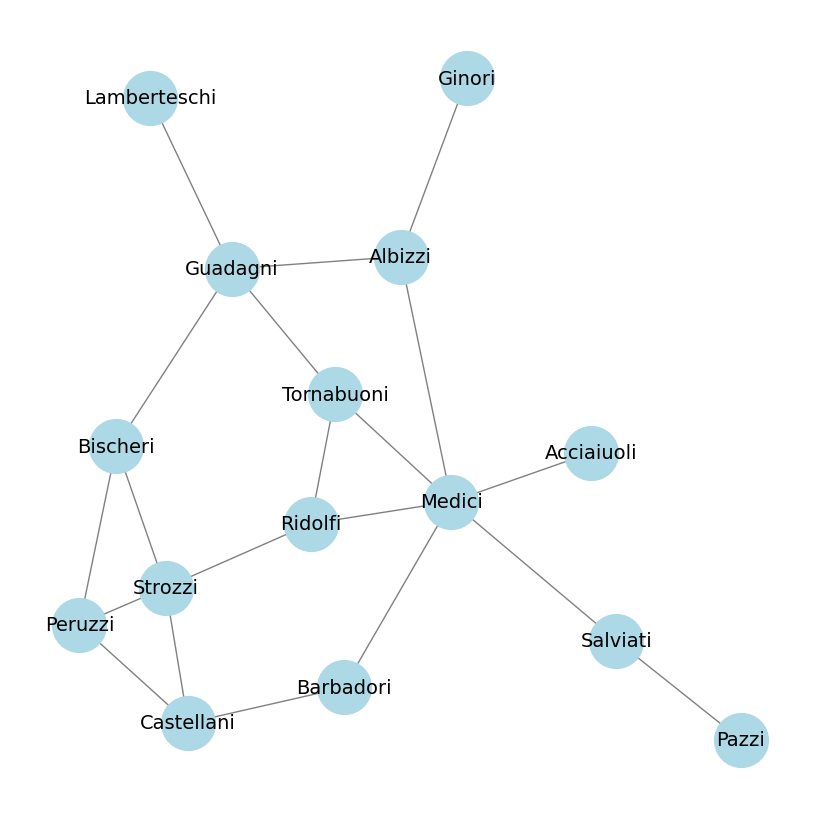

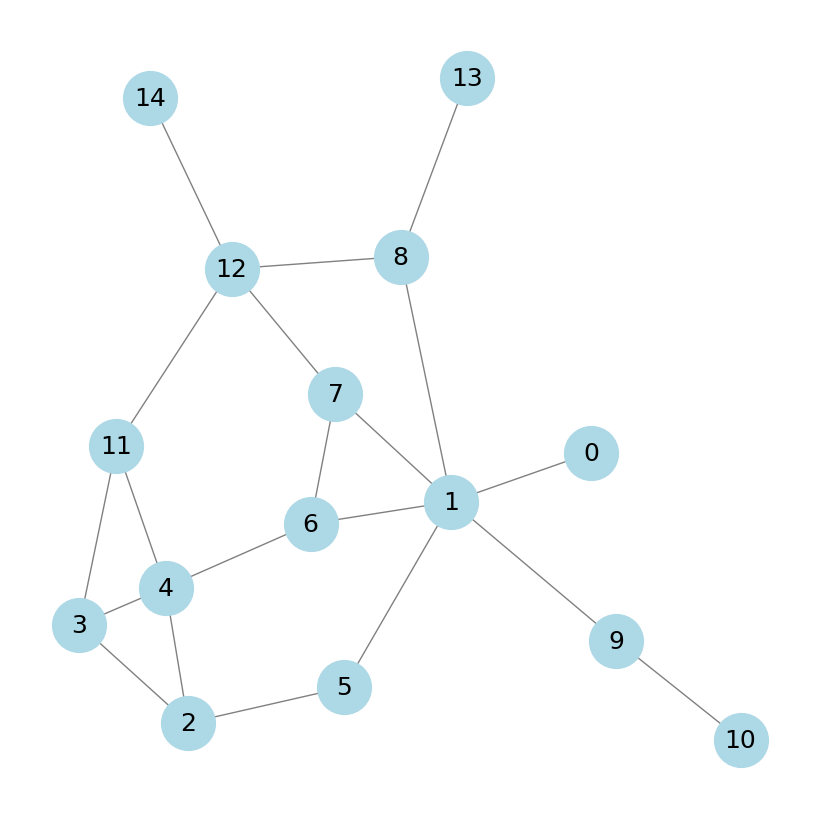

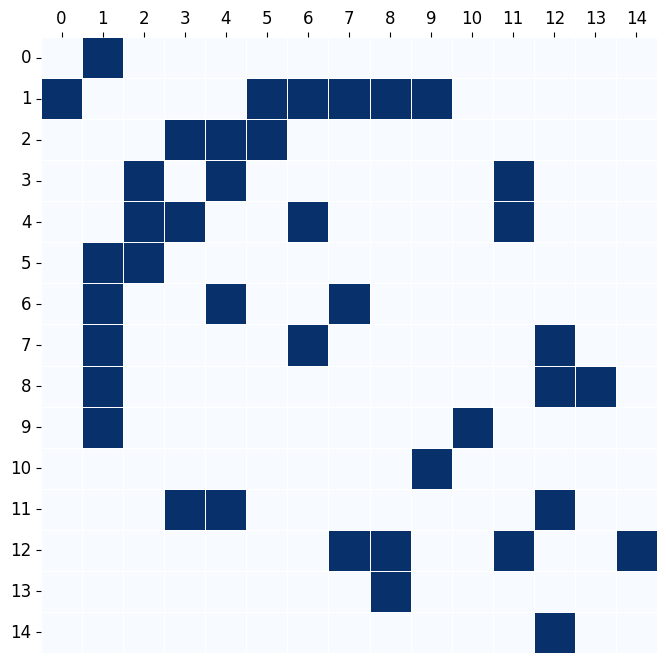

In [4]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G,seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
n = Y.shape[0]
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

In [5]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 20000
n_sim_iv = 2000
n_iter_cv = 2000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

Multi_start (1)


MAP:   8%|▊         | 1652/20000 [00:11<02:12, 138.61it/s, logpost=-43.2681, loglik=-42.7187, logprior=-0.5494, ||grad||=0.0132, patience=100]


[STOP] Early stopping at iter 1651 (no improvement in 101 steps)

Best log-posterior: -43.2681


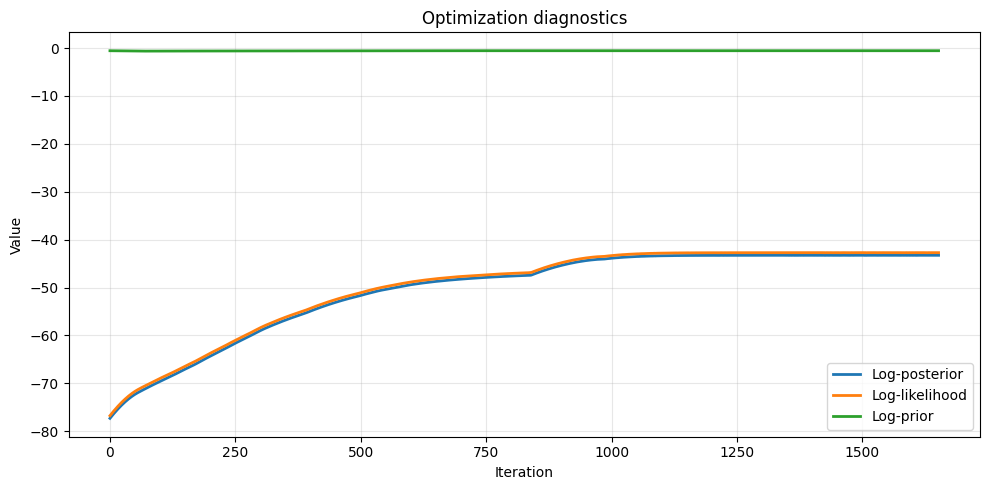

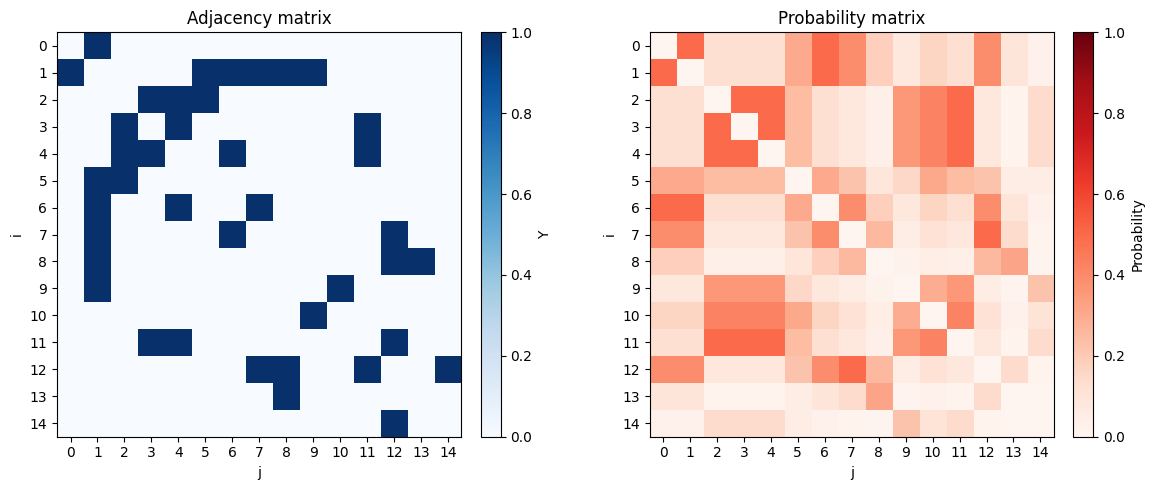

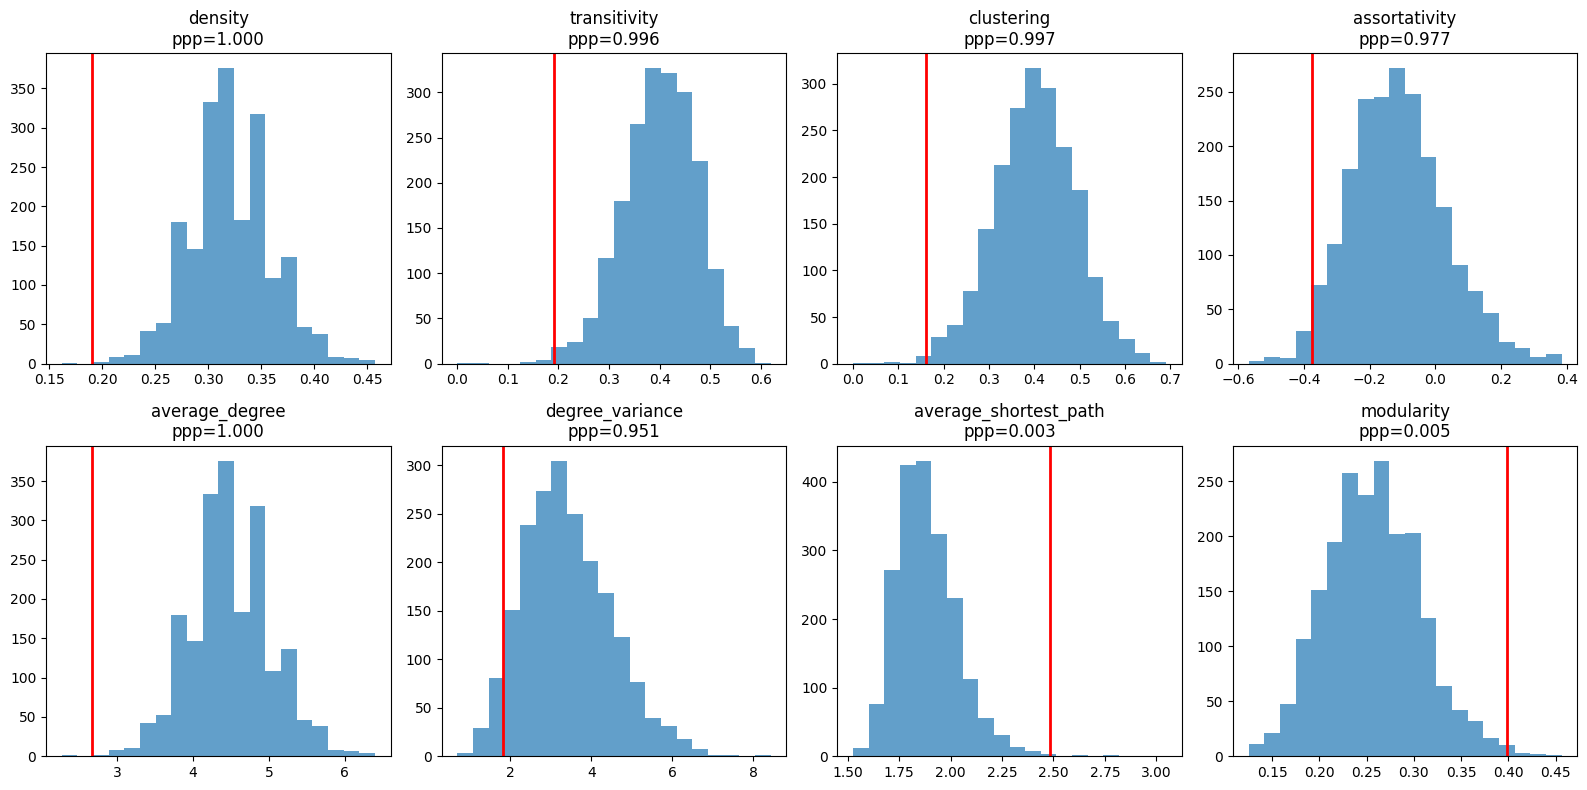

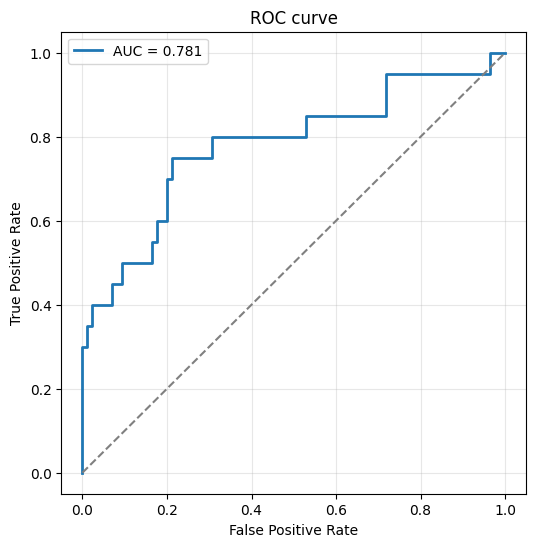

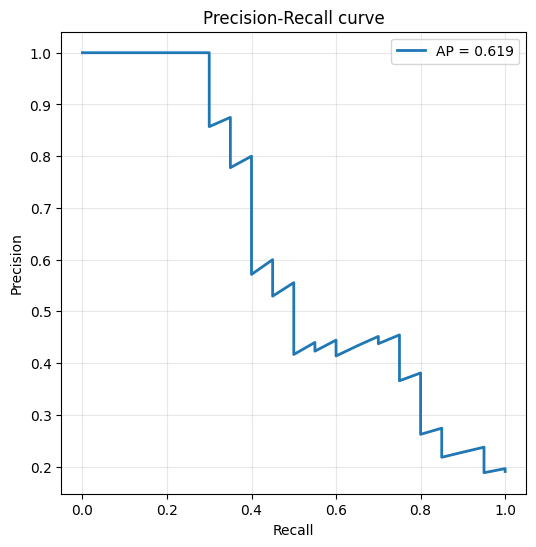

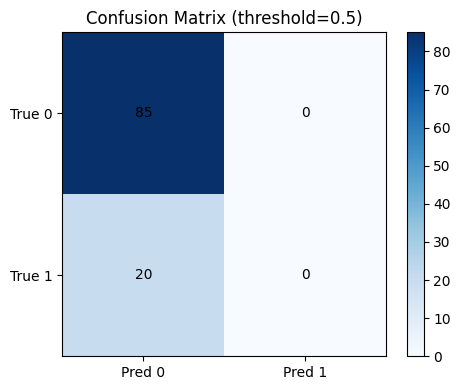

MAP: 100%|██████████| 2000/2000 [00:13<00:00, 148.14it/s, logpost=-27.9722, loglik=-27.4228, logprior=-0.5494, ||grad||=0.0127, patience=2] 


{'mean_auc': 0.6935460382983603, 'std_auc': 0.13378120629868037, 'min_auc': np.float64(0.5444444444444444), 'max_auc': np.float64(0.9210526315789473), 'n_folds': 5}


In [6]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_c.pkl")

#### With weights

Multi_start (1)


MAP:   0%|          | 0/20000 [00:00<?, ?it/s]

MAP:  13%|█▎        | 2632/20000 [00:11<01:17, 223.51it/s, logpost=-36.8662, loglik=-36.8662, logprior=0.0000, ||grad||=0.0099, patience=100]


[STOP] Early stopping at iter 2631 (no improvement in 101 steps)

Best log-posterior: -36.8662


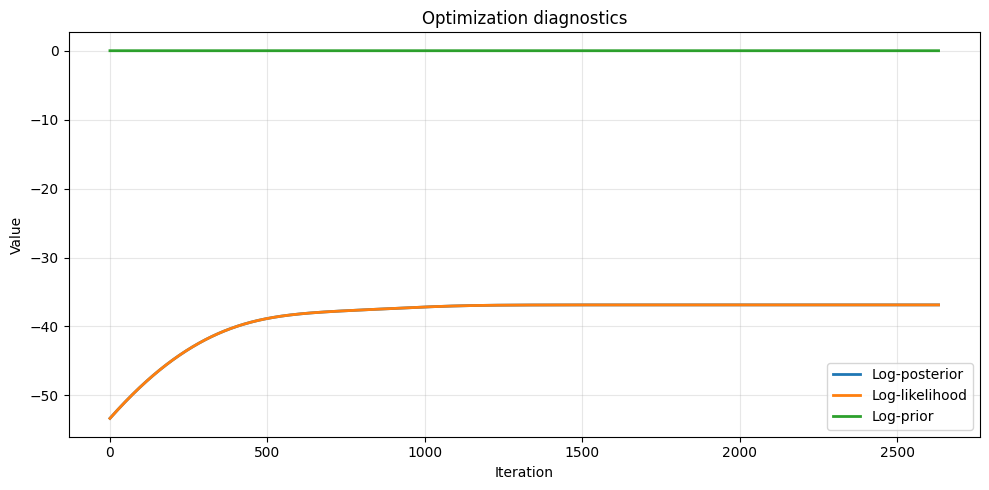

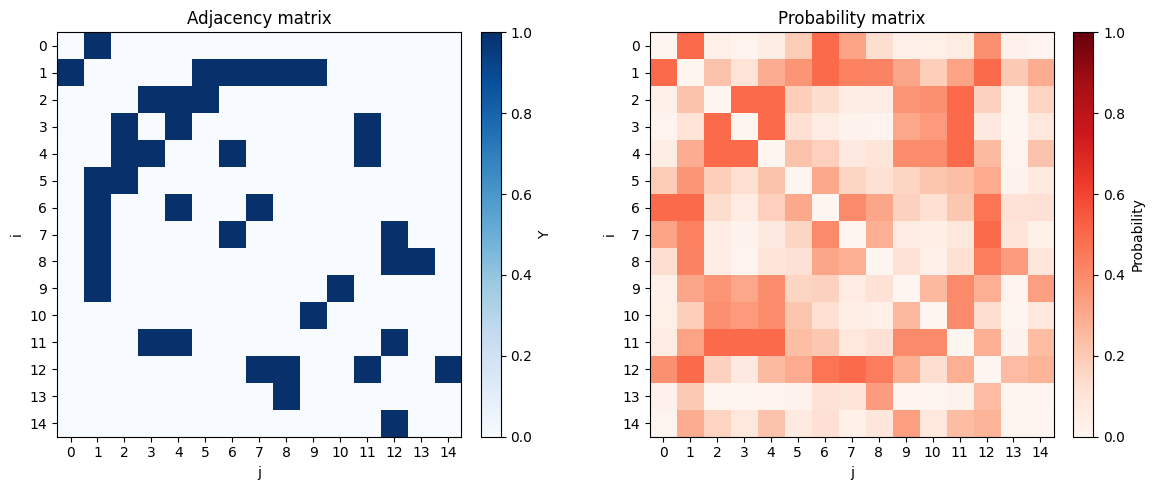

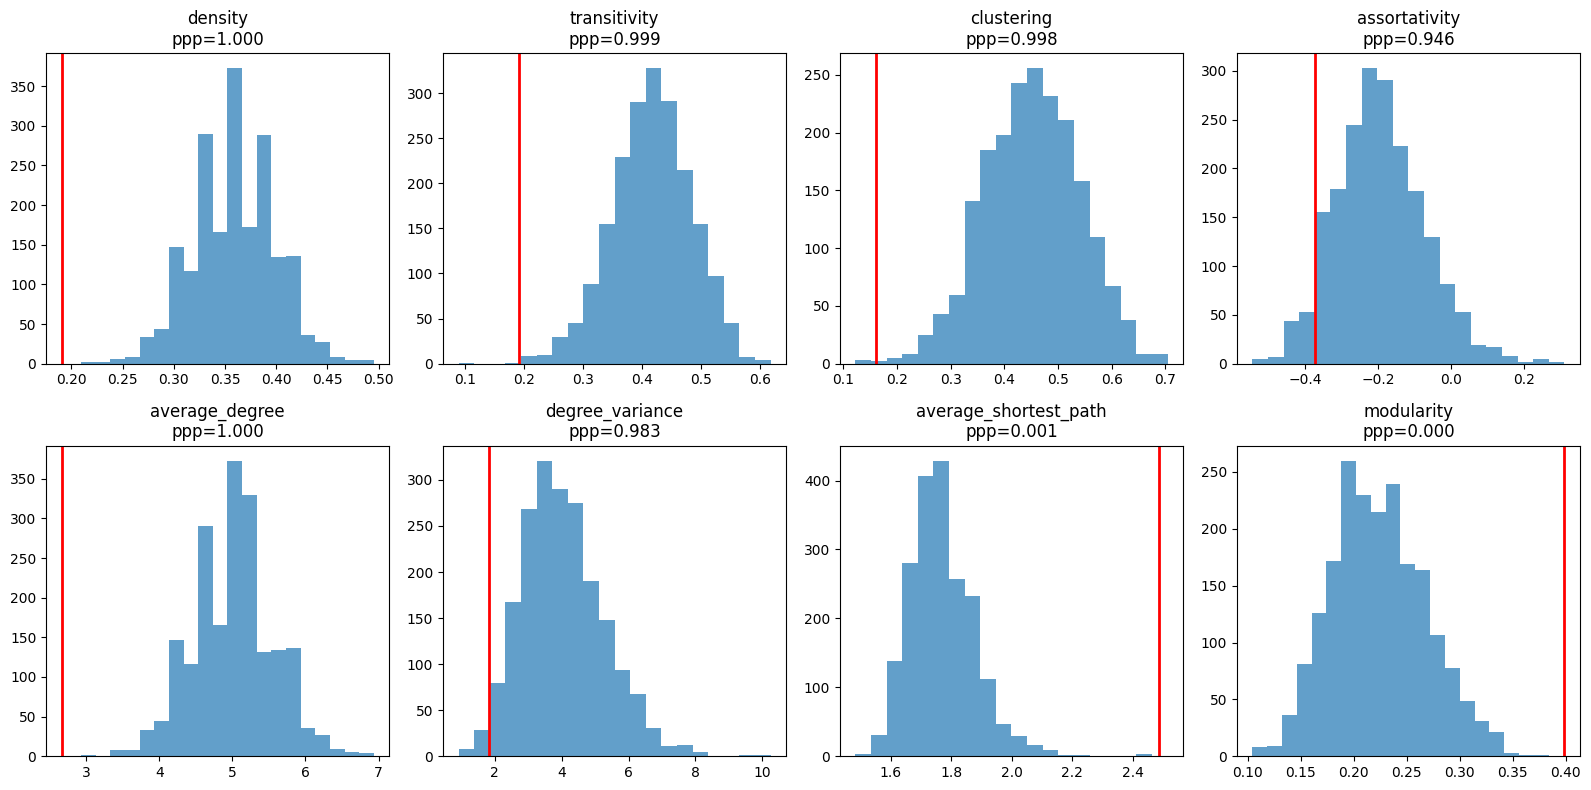

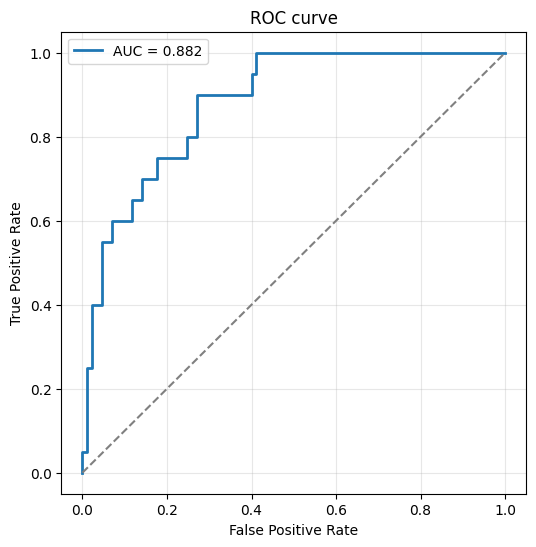

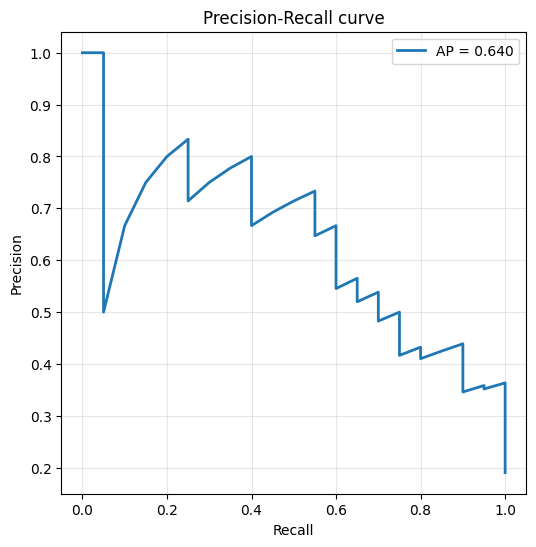

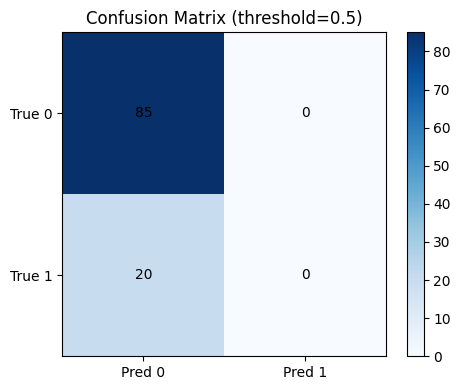

MAP: 100%|██████████| 2000/2000 [00:07<00:00, 263.01it/s, logpost=-25.4612, loglik=-25.4612, logprior=0.0000, ||grad||=0.0099, patience=1]


{'mean_auc': 0.7739207086343309, 'std_auc': 0.07735928642746032, 'min_auc': np.float64(0.6777777777777778), 'max_auc': np.float64(0.9125), 'n_folds': 5}


In [8]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

Multi_start (1)


MAP:  32%|███▏      | 6426/20000 [00:52<01:50, 123.10it/s, logpost=-22.2331, loglik=-20.2970, logprior=-1.9362, ||grad||=0.0127, patience=100]


[STOP] Early stopping at iter 6425 (no improvement in 101 steps)

Best log-posterior: -22.2331


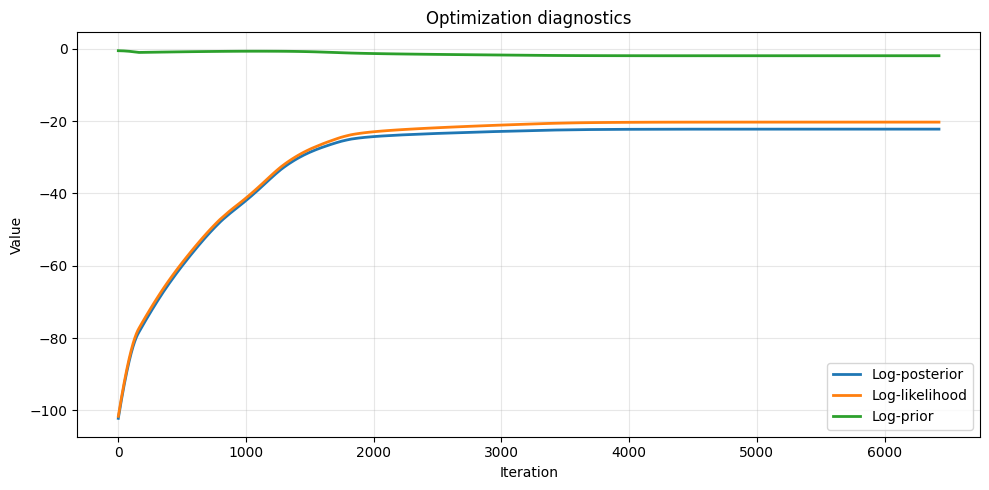

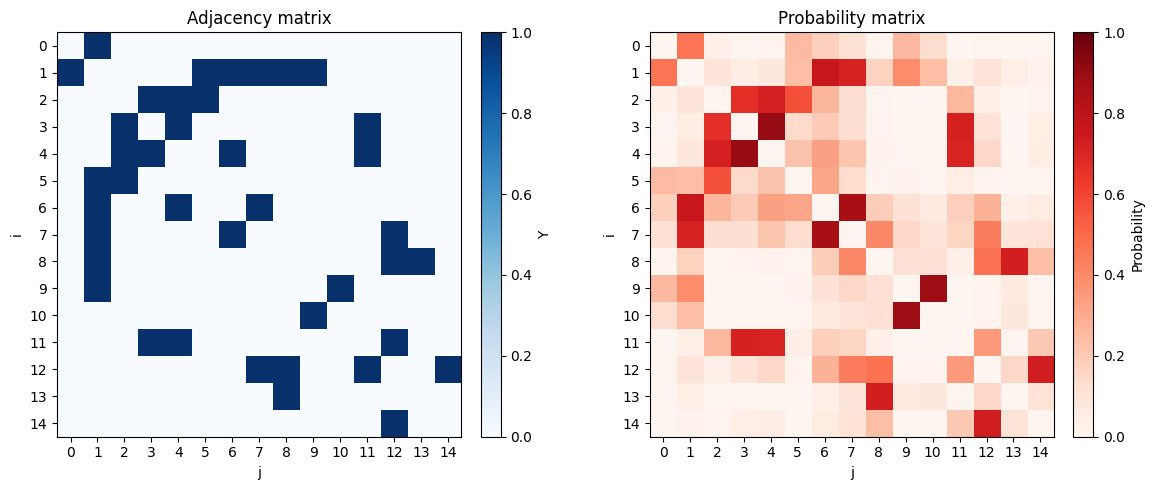

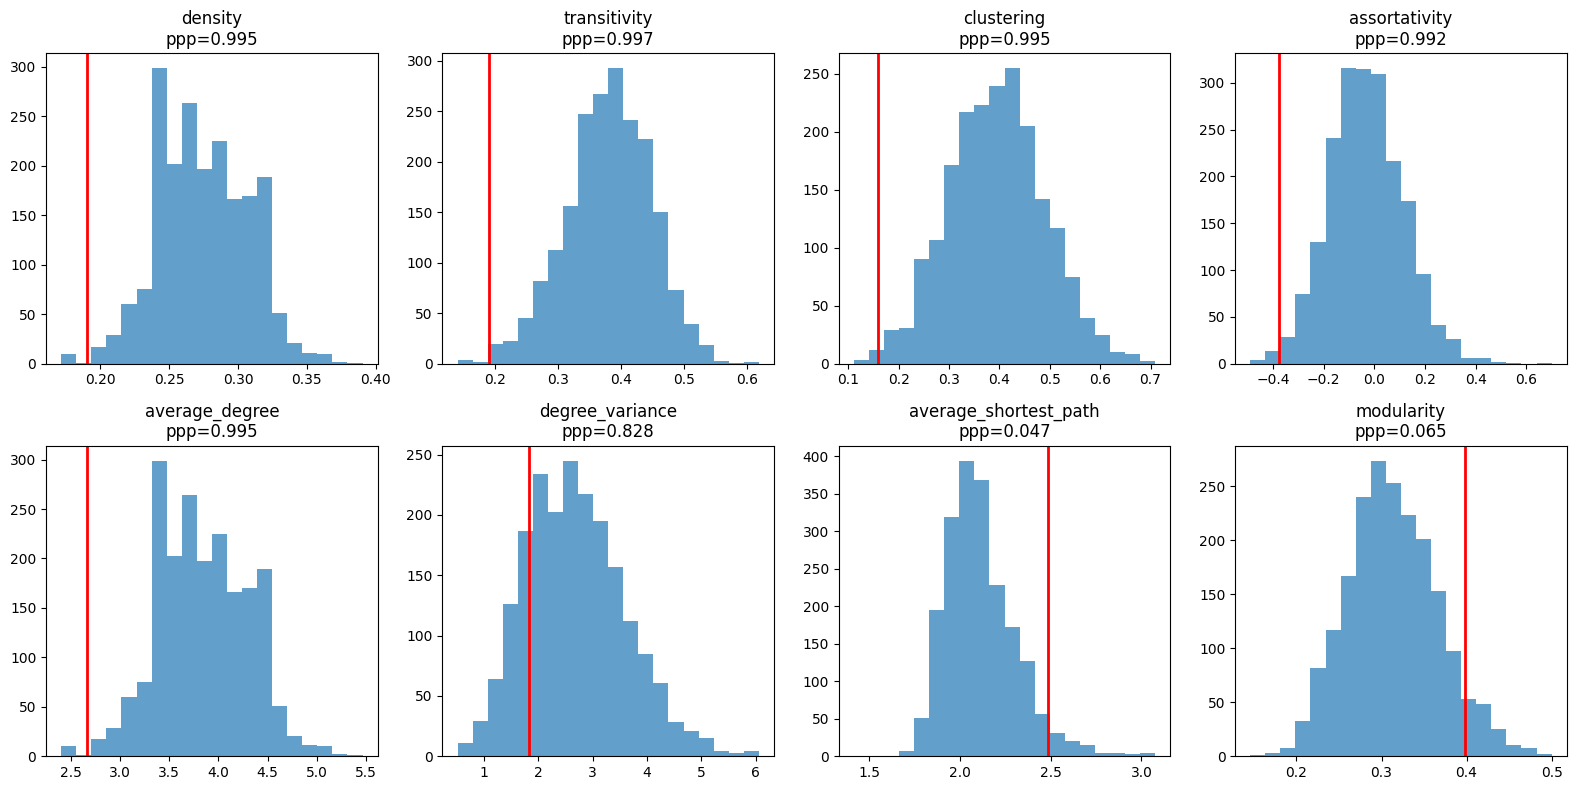

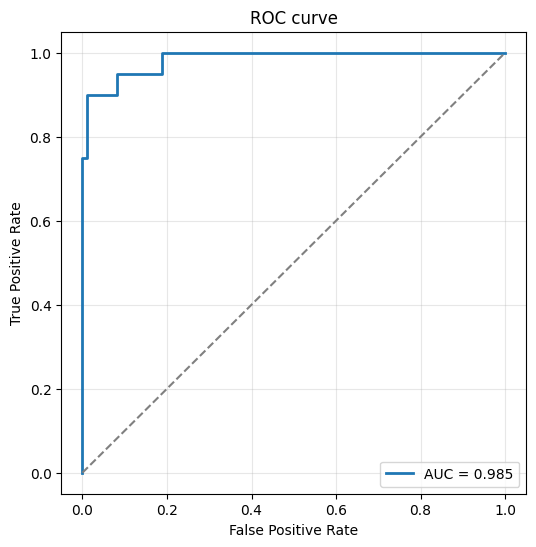

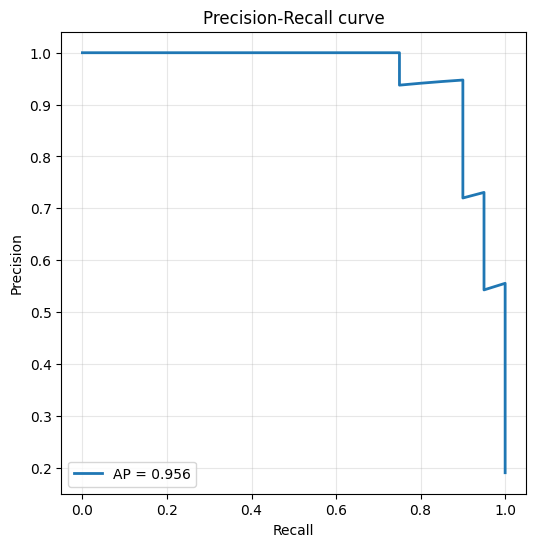

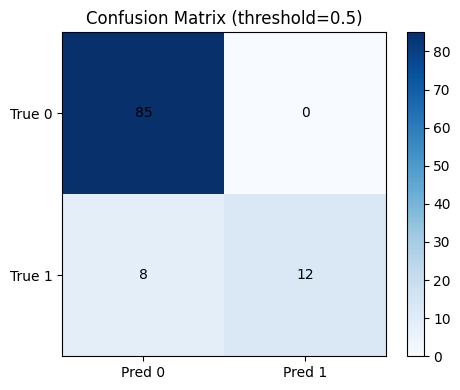

MAP: 100%|██████████| 2000/2000 [00:13<00:00, 146.31it/s, logpost=-11.9170, loglik=-10.3826, logprior=-1.5345, ||grad||=0.0120, patience=0]


{'mean_auc': 0.7525728127508314, 'std_auc': 0.17460910159412876, 'min_auc': np.float64(0.5375), 'max_auc': np.float64(0.9705882352941176), 'n_folds': 5}


In [9]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_c.pkl")

#### With weights

Multi_start (1)


MAP:   4%|▍         | 889/20000 [00:05<01:48, 176.22it/s, logpost=-17.6571, loglik=-17.6571, logprior=0.0000, ||grad||=0.0072, patience=100]


[STOP] Early stopping at iter 888 (no improvement in 101 steps)

Best log-posterior: -17.6571


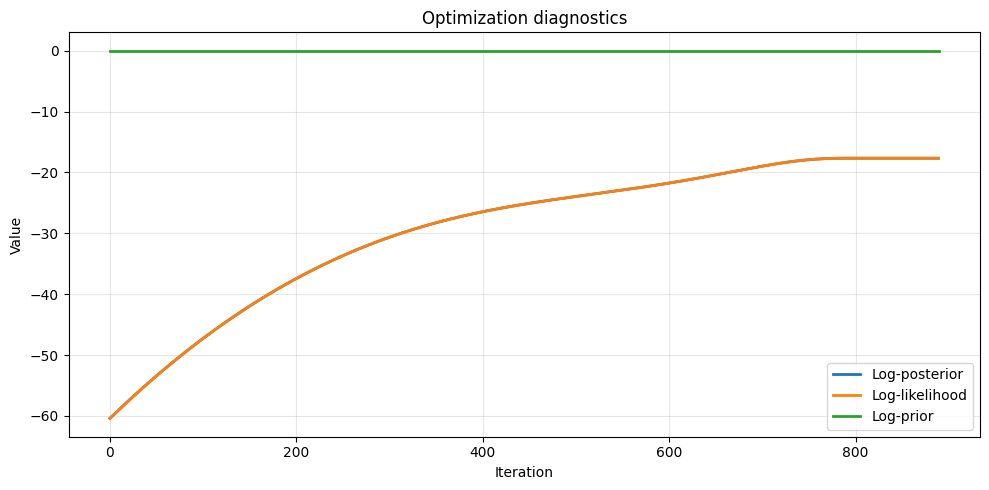

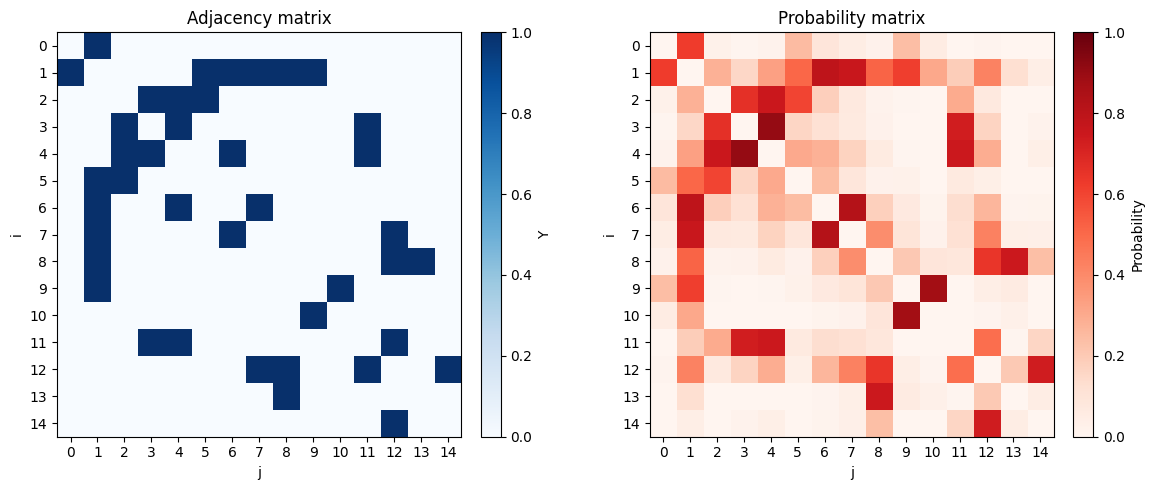

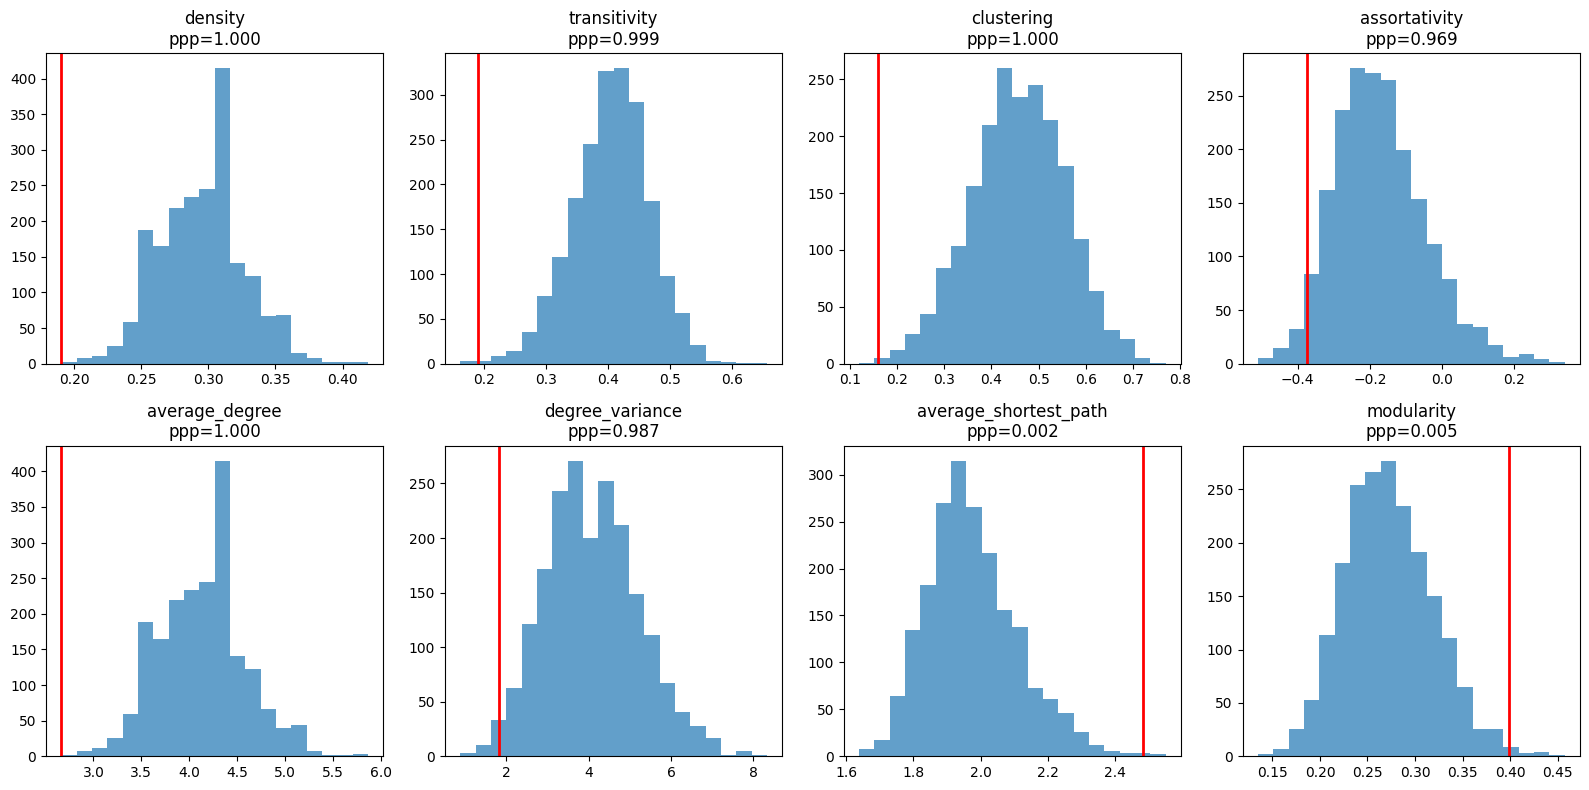

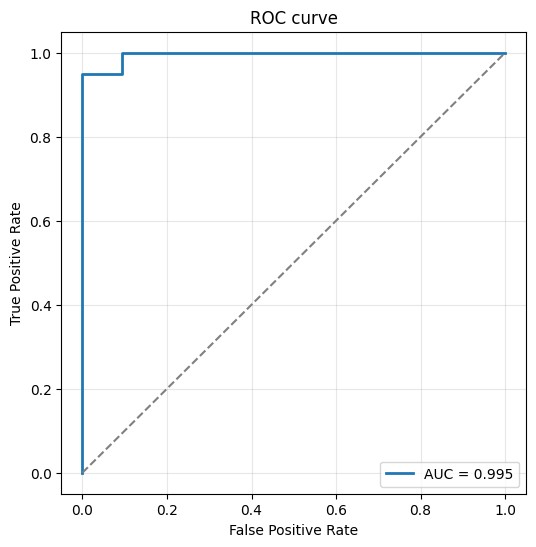

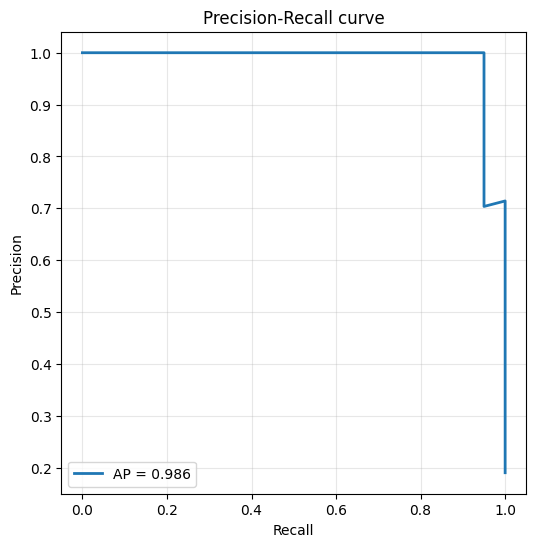

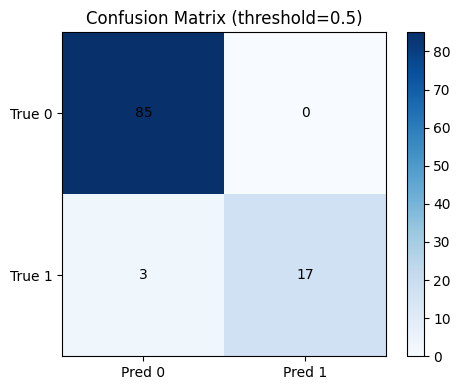

MAP:   6%|▌         | 119/2000 [00:01<00:21, 88.33it/s, logpost=-11.5218, loglik=-11.5218, logprior=0.0000, ||grad||=0.0068, patience=49]


{'mean_auc': 0.9450653594771243, 'std_auc': 0.0333727819883371, 'min_auc': np.float64(0.9), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [10]:
geometry = EuclideanGeometry(d=2)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:25<00:00, 234.67it/s, logpost=-39.2298, loglik=-38.6686, logprior=-0.5612, patience=21]



Best log-posterior: -39.2298


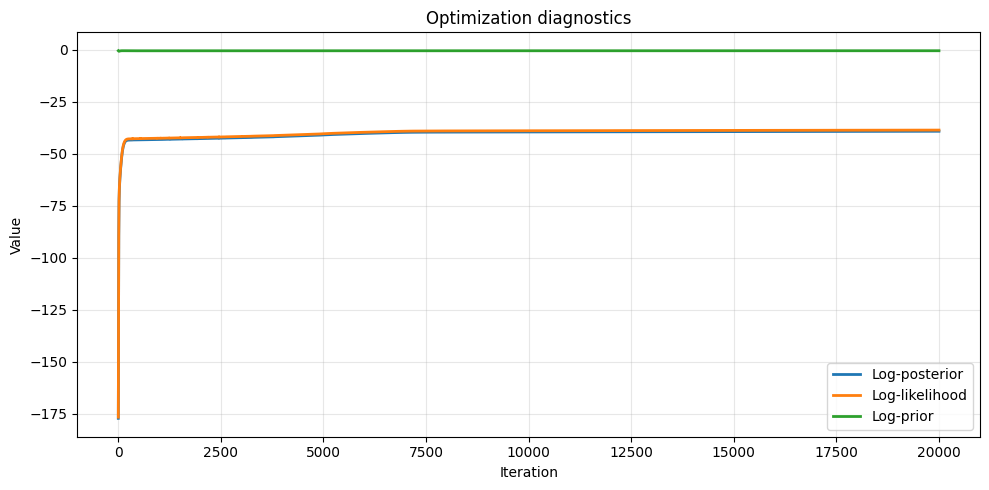

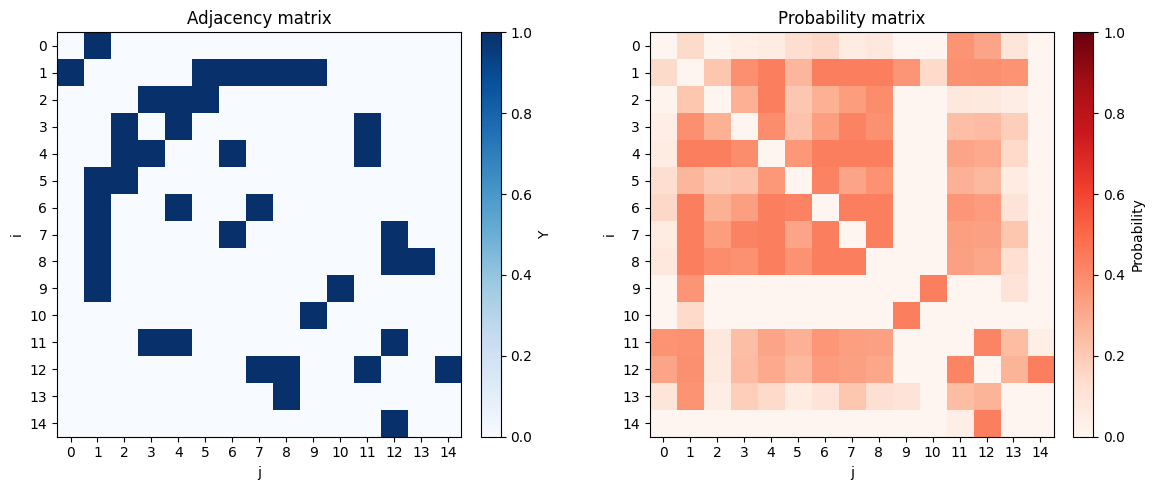

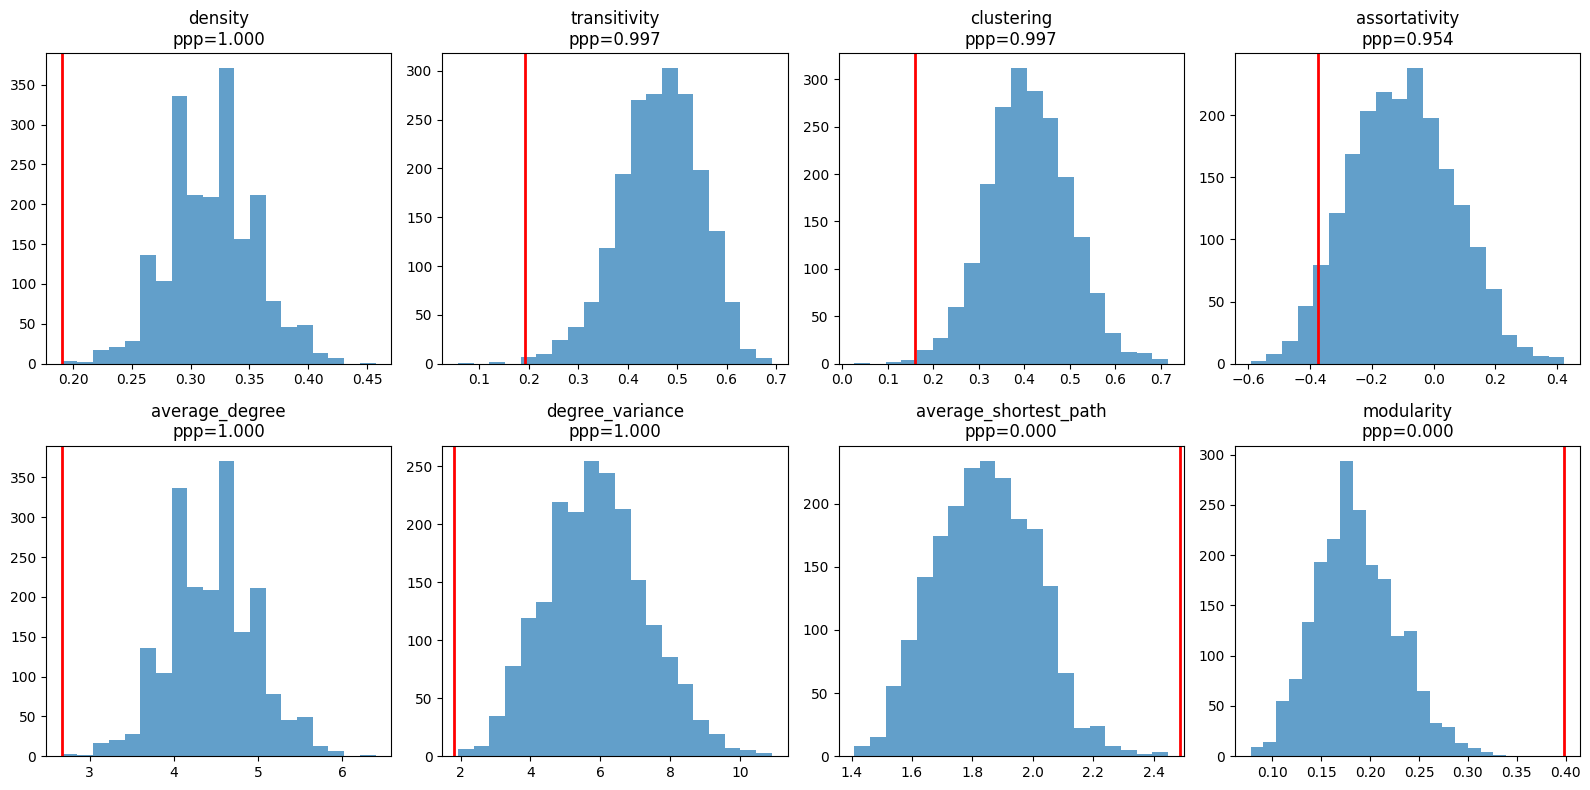

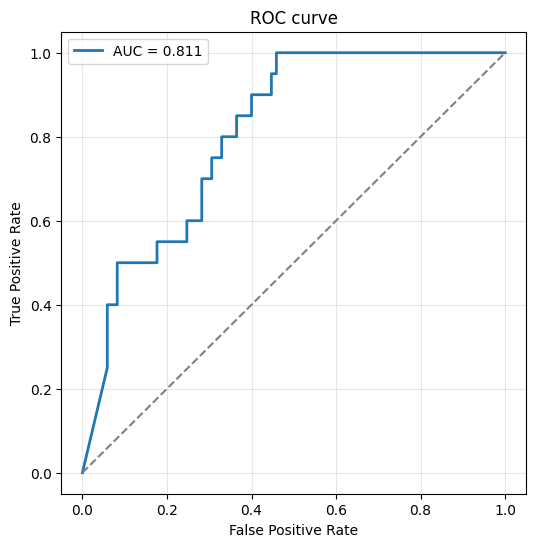

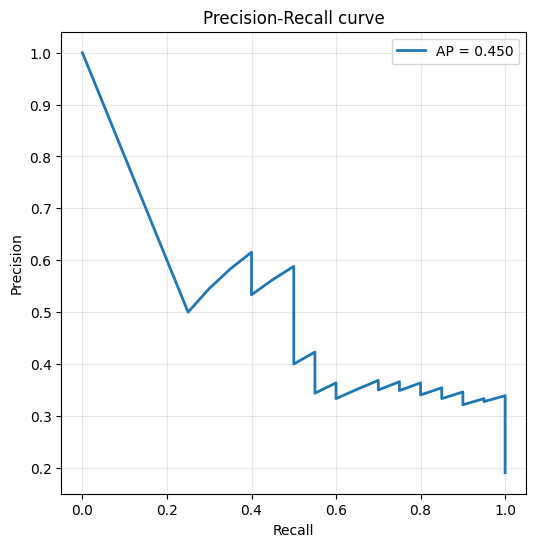

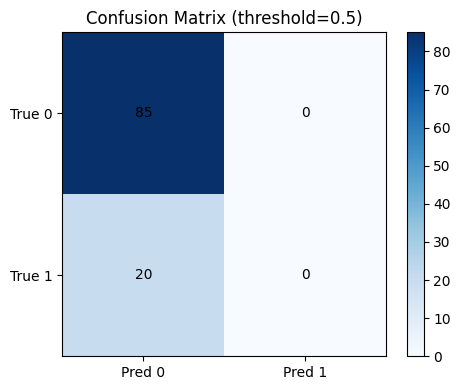

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.17it/s, logpost=-22.2877, loglik=-21.7229, logprior=-0.5648, patience=0]


{'mean_auc': 0.4920992432060543, 'std_auc': 0.10832485792218284, 'min_auc': np.float64(0.368421052631579), 'max_auc': np.float64(0.6323529411764706), 'n_folds': 5}


In [8]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_p.pkl")

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:24<00:00, 237.52it/s, logpost=-106.7987, loglik=-105.4821, logprior=-1.3166, patience=0]



Best log-posterior: -106.7987


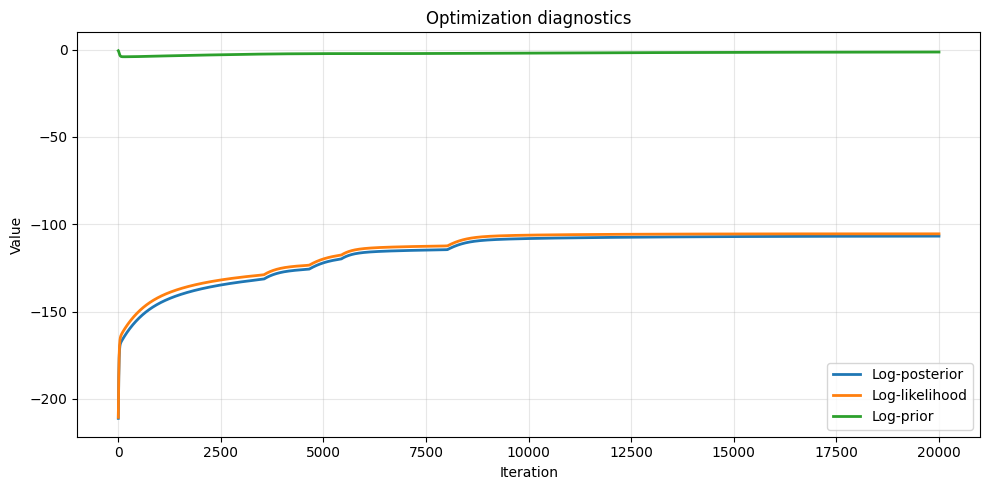

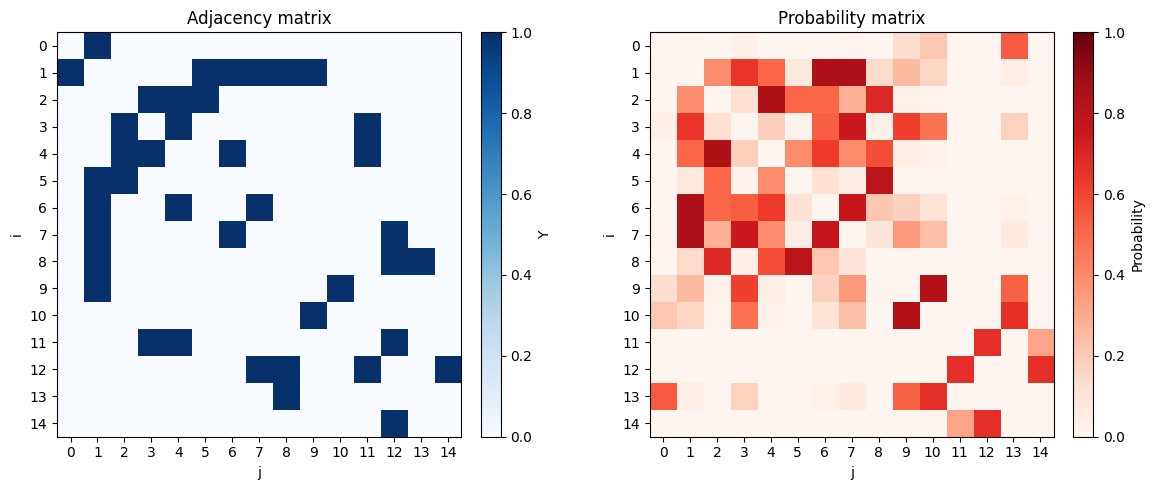

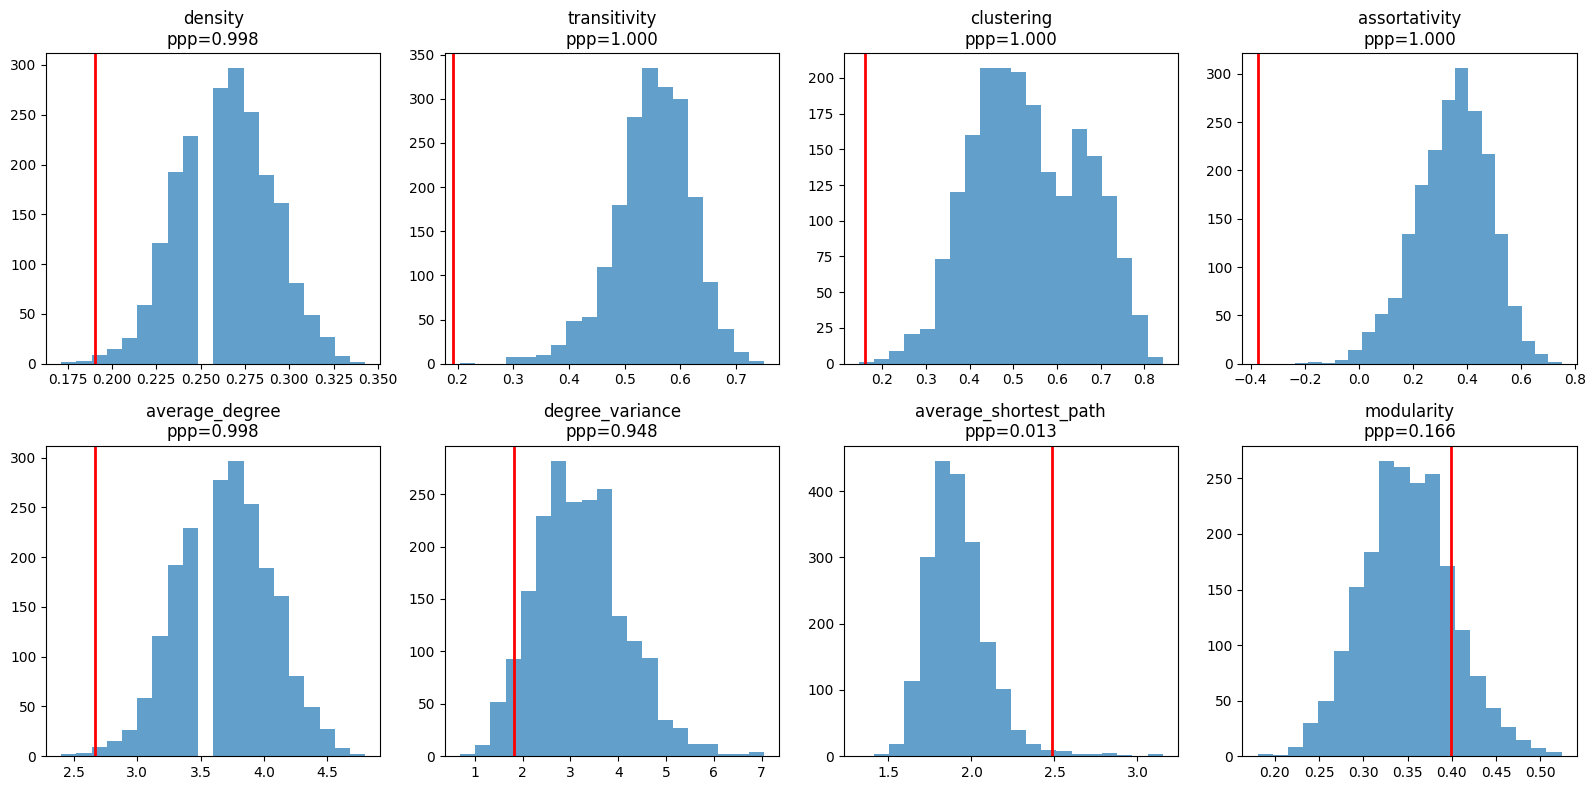

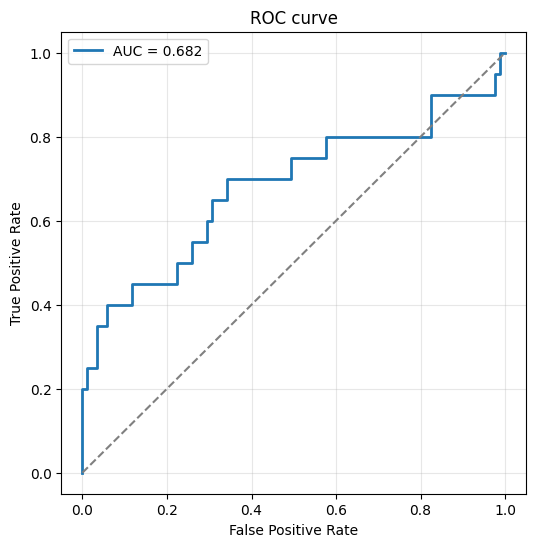

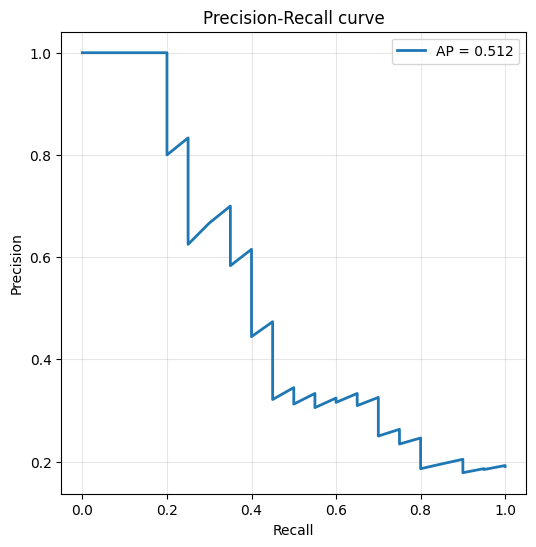

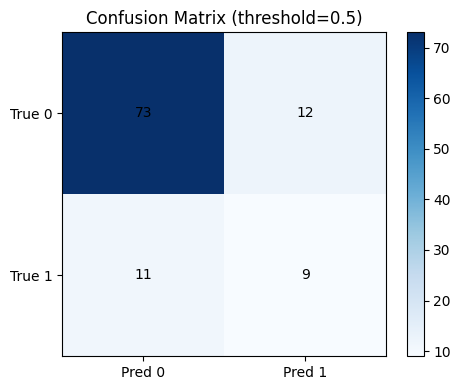

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.96it/s, logpost=-60.9752, loglik=-60.1107, logprior=-0.8645, patience=0]


{'mean_auc': 0.5879087833963995, 'std_auc': 0.13696733297895725, 'min_auc': np.float64(0.4210526315789474), 'max_auc': np.float64(0.7625000000000001), 'n_folds': 5}


In [9]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_c.pkl")

### Model $\mathbb{S}^2$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:30<00:00, 220.43it/s, logpost=-27.1036, loglik=-26.1813, logprior=-0.9223, patience=0]



Best log-posterior: -27.1036


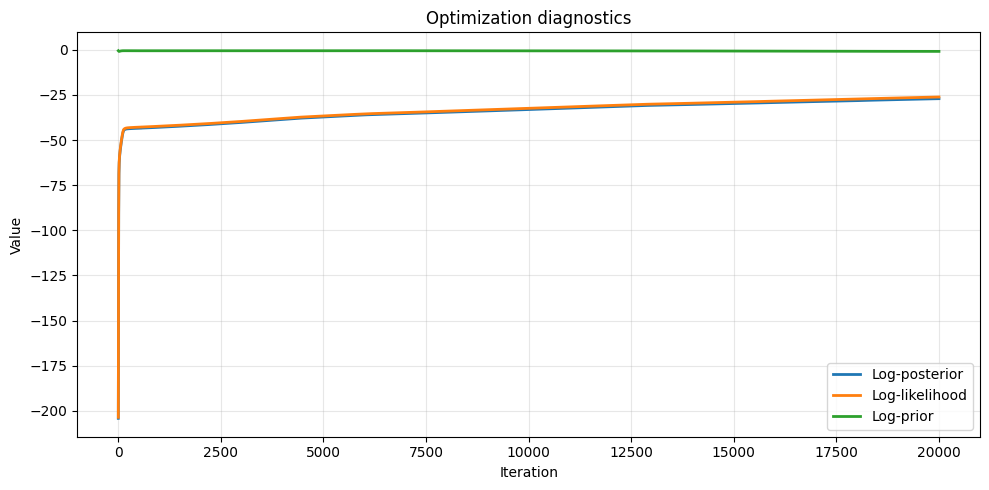

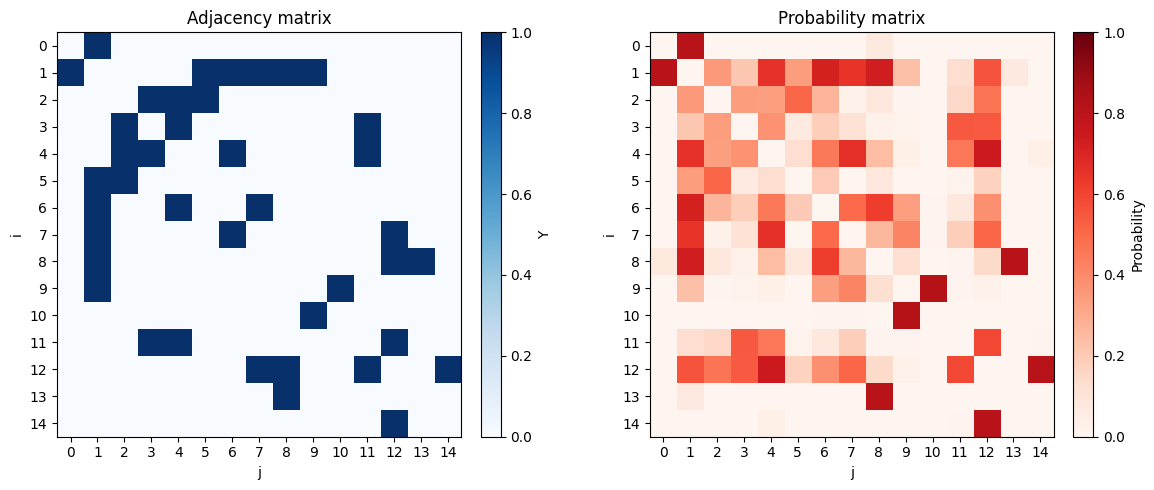

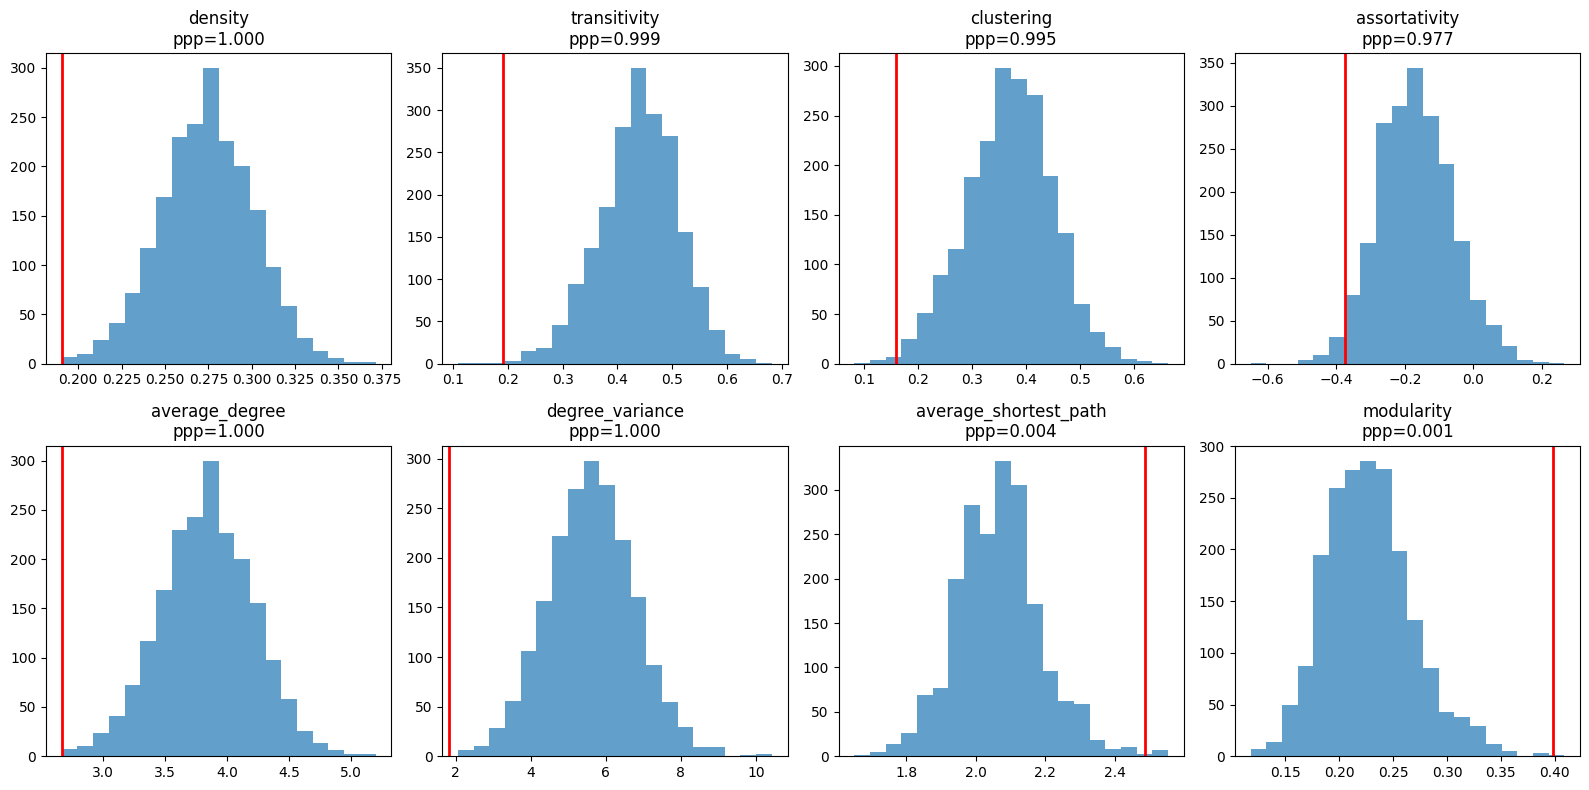

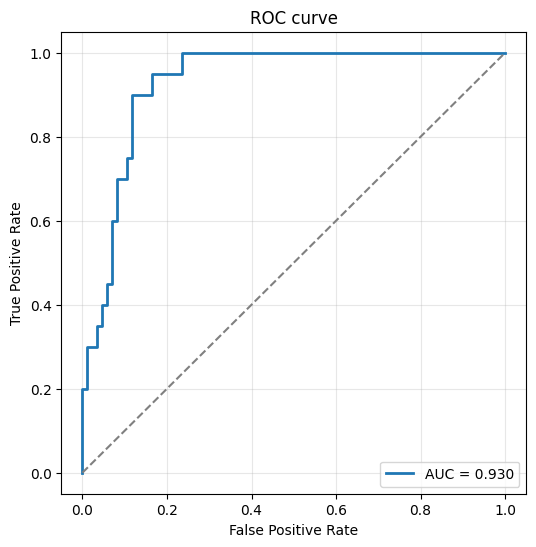

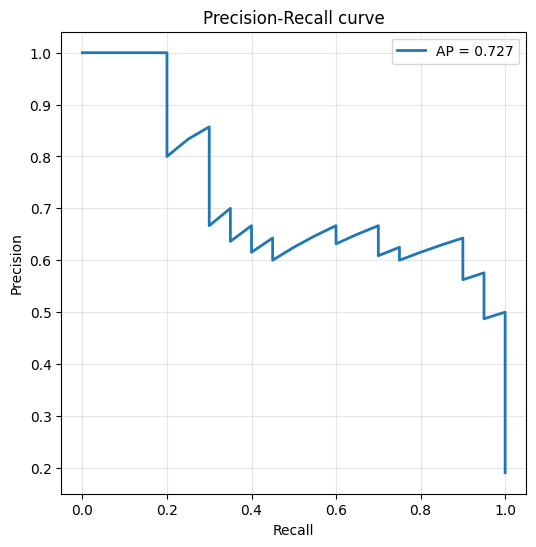

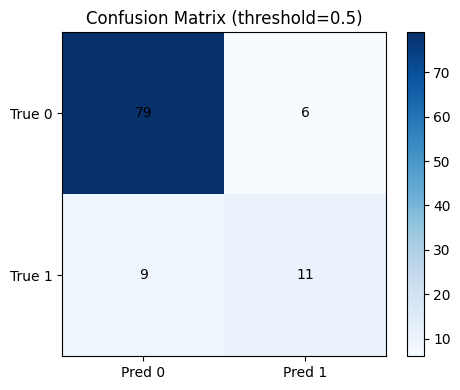

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.79it/s, logpost=-14.3584, loglik=-13.2009, logprior=-1.1576, patience=0]


{'mean_auc': 0.7529325765393876, 'std_auc': 0.13877022901418076, 'min_auc': np.float64(0.575), 'max_auc': np.float64(0.9444444444444444), 'n_folds': 5}


In [10]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_p.pkl")

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:29<00:00, 222.58it/s, logpost=-24.6817, loglik=-21.1320, logprior=-3.5497, patience=0]



Best log-posterior: -24.6817


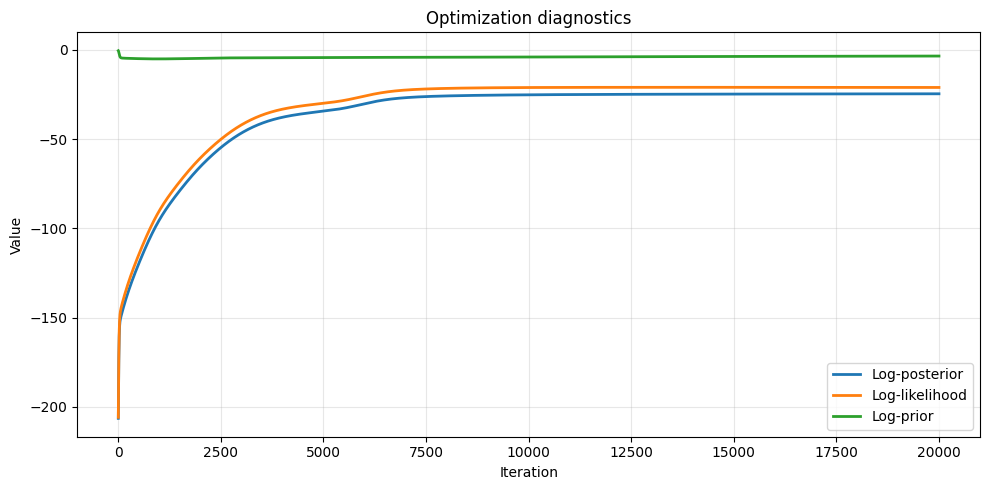

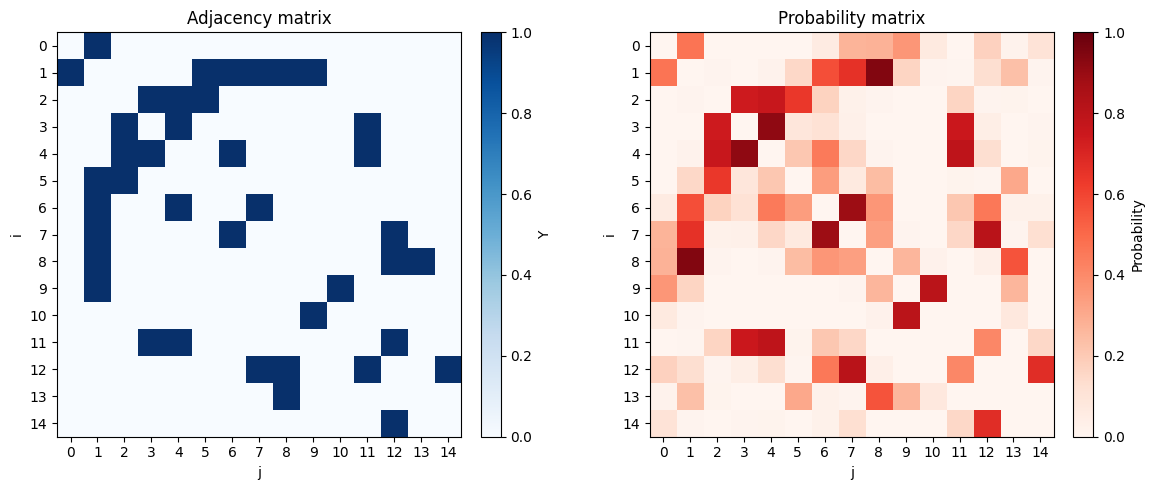

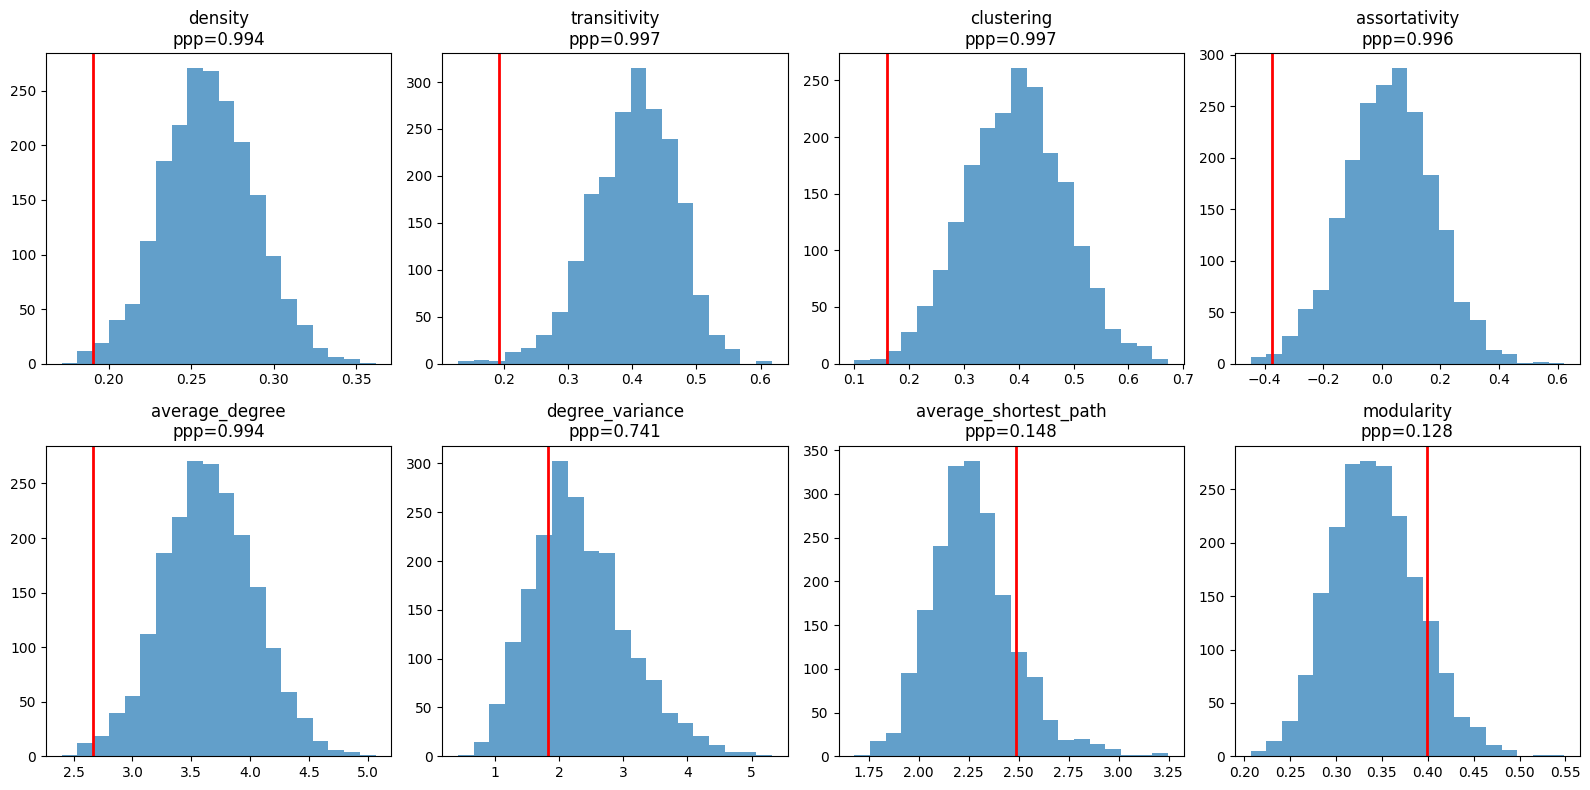

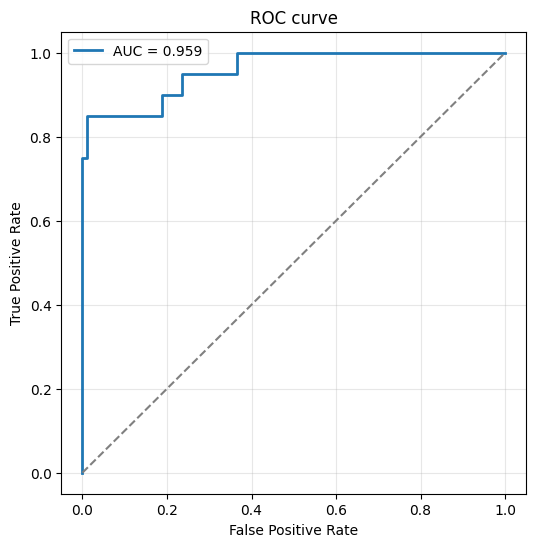

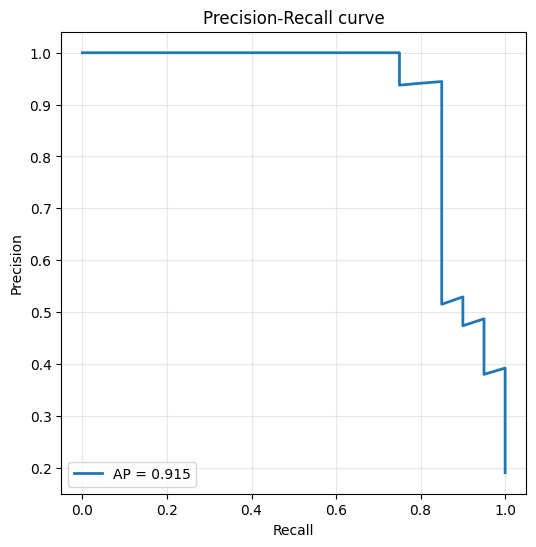

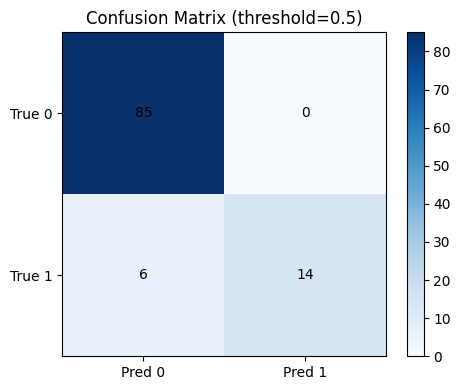

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 209.69it/s, logpost=-11.5656, loglik=-8.8165, logprior=-2.7491, patience=0]


{'mean_auc': 0.8893102855177158, 'std_auc': 0.07027938620928526, 'min_auc': np.float64(0.8), 'max_auc': np.float64(0.9852941176470588), 'n_folds': 5}


In [11]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_c.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### With weights

Multi_start (1)


MAP:   1%|          | 150/20000 [00:01<03:25, 96.63it/s, logpost=-67.6058, loglik=-67.0552, logprior=-0.5506, patience=100] 


[STOP] Early stopping at iter 149 (no improvement in 101 steps)

Best log-posterior: -67.6058


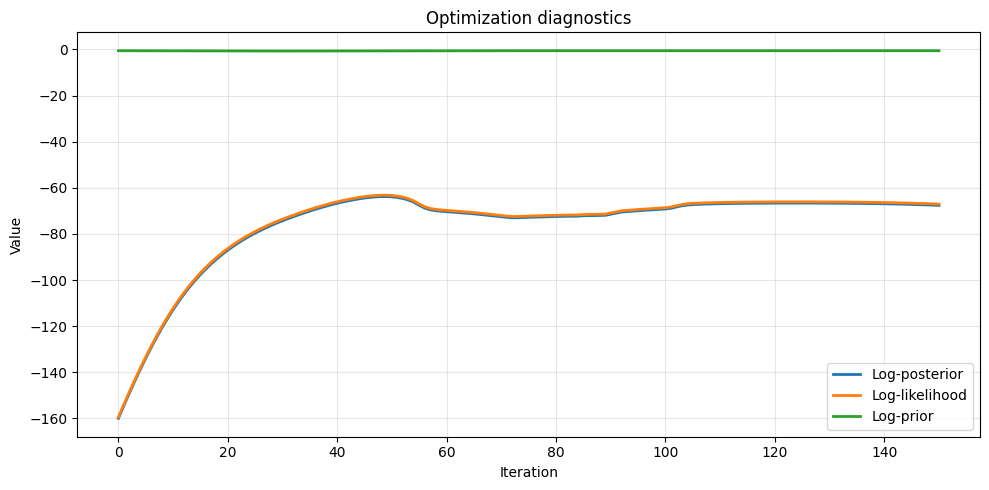

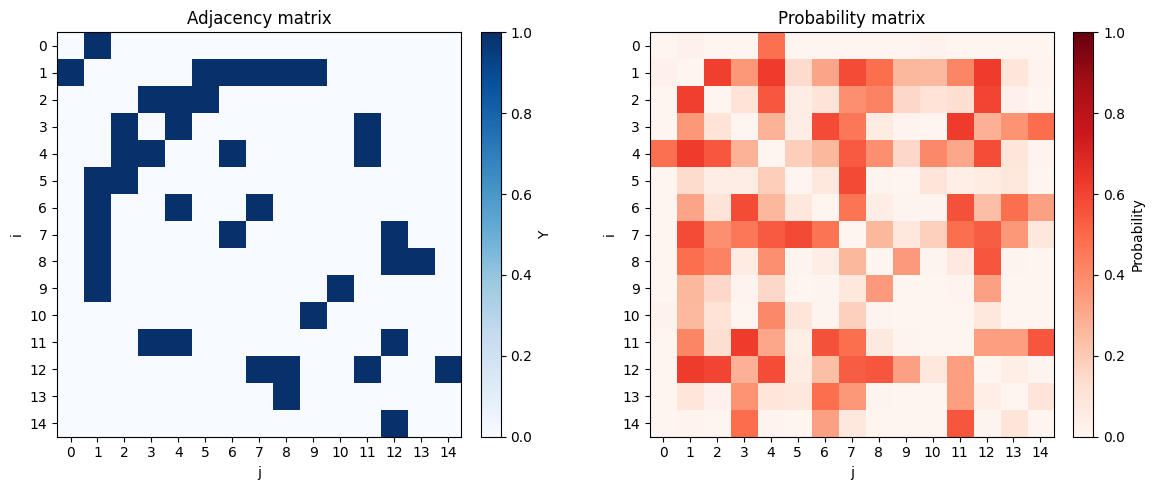

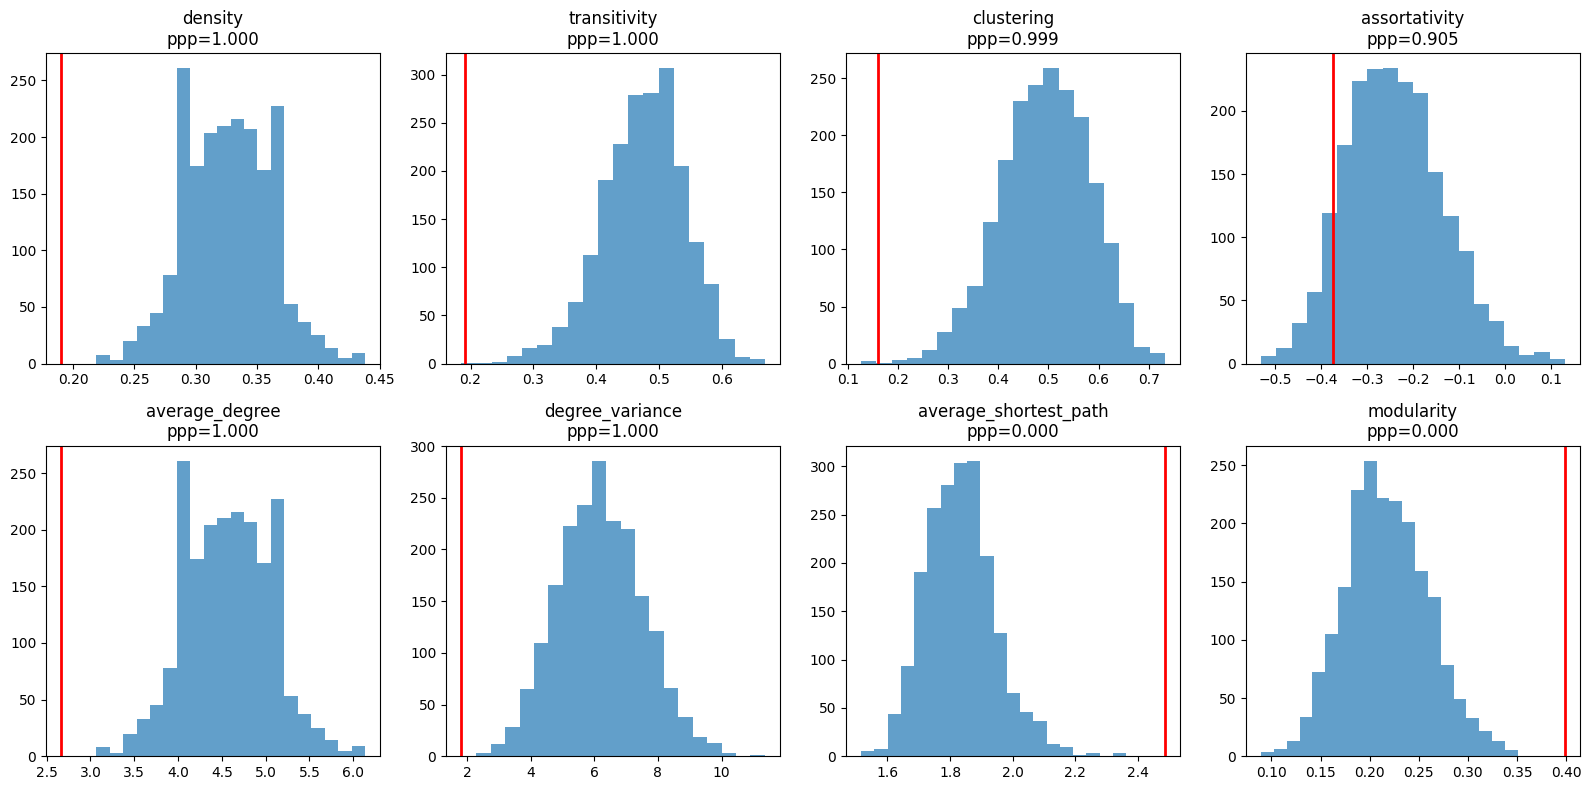

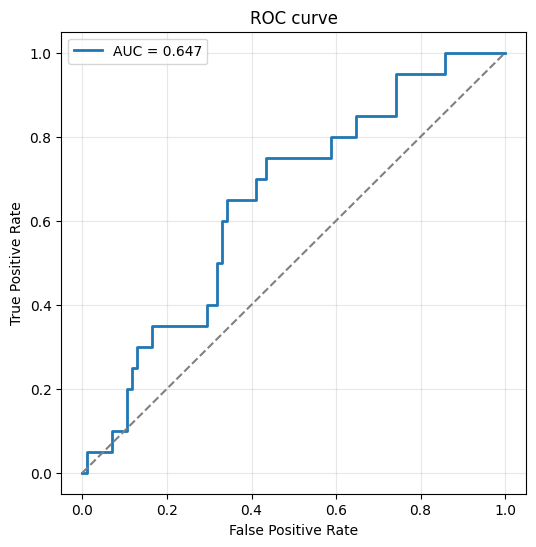

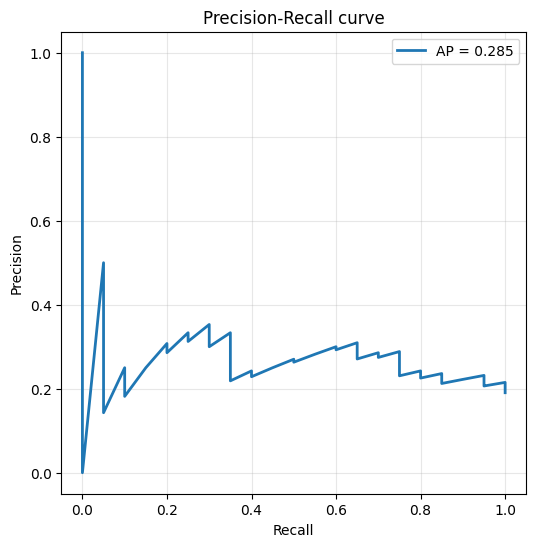

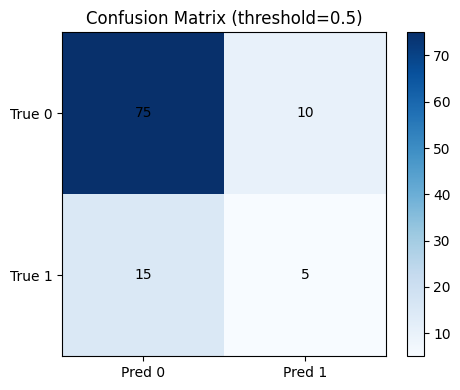

MAP:   2%|▎         | 50/2000 [00:00<00:34, 57.10it/s, logpost=-49.2664, loglik=-48.7168, logprior=-0.5496, patience=49]


{'mean_auc': 0.45500171998624006, 'std_auc': 0.19390022620497532, 'min_auc': np.float64(0.17647058823529413), 'max_auc': np.float64(0.6499999999999999), 'n_folds': 5}


In [12]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_p.pkl")

#### Without weights

Multi_start (1)


MAP:   1%|          | 150/20000 [00:01<02:51, 116.03it/s, logpost=-113.6586, loglik=-112.5874, logprior=-1.0712, patience=100]


[STOP] Early stopping at iter 149 (no improvement in 101 steps)

Best log-posterior: -113.6586


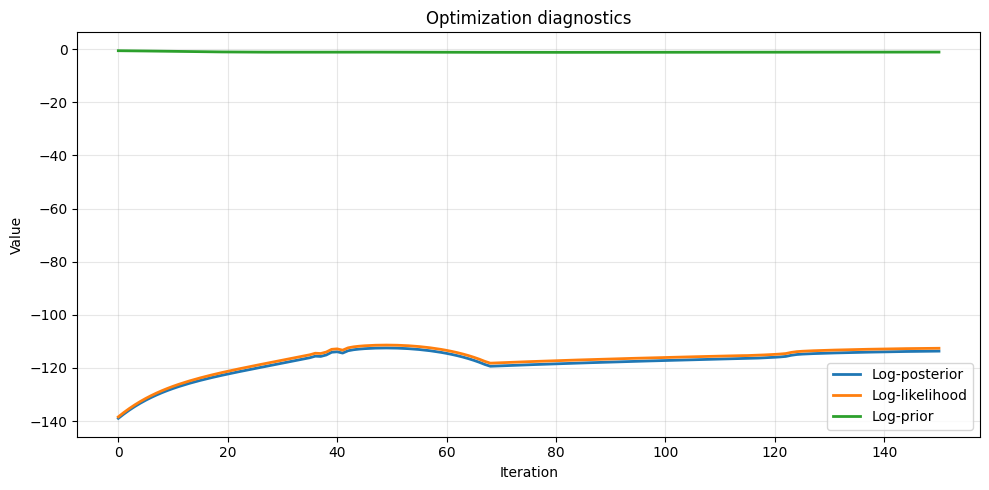

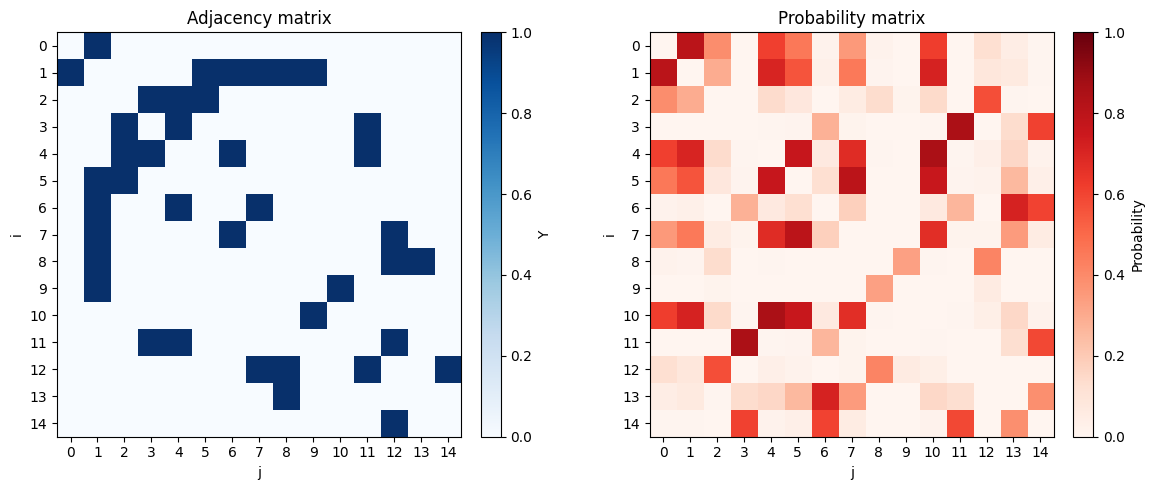

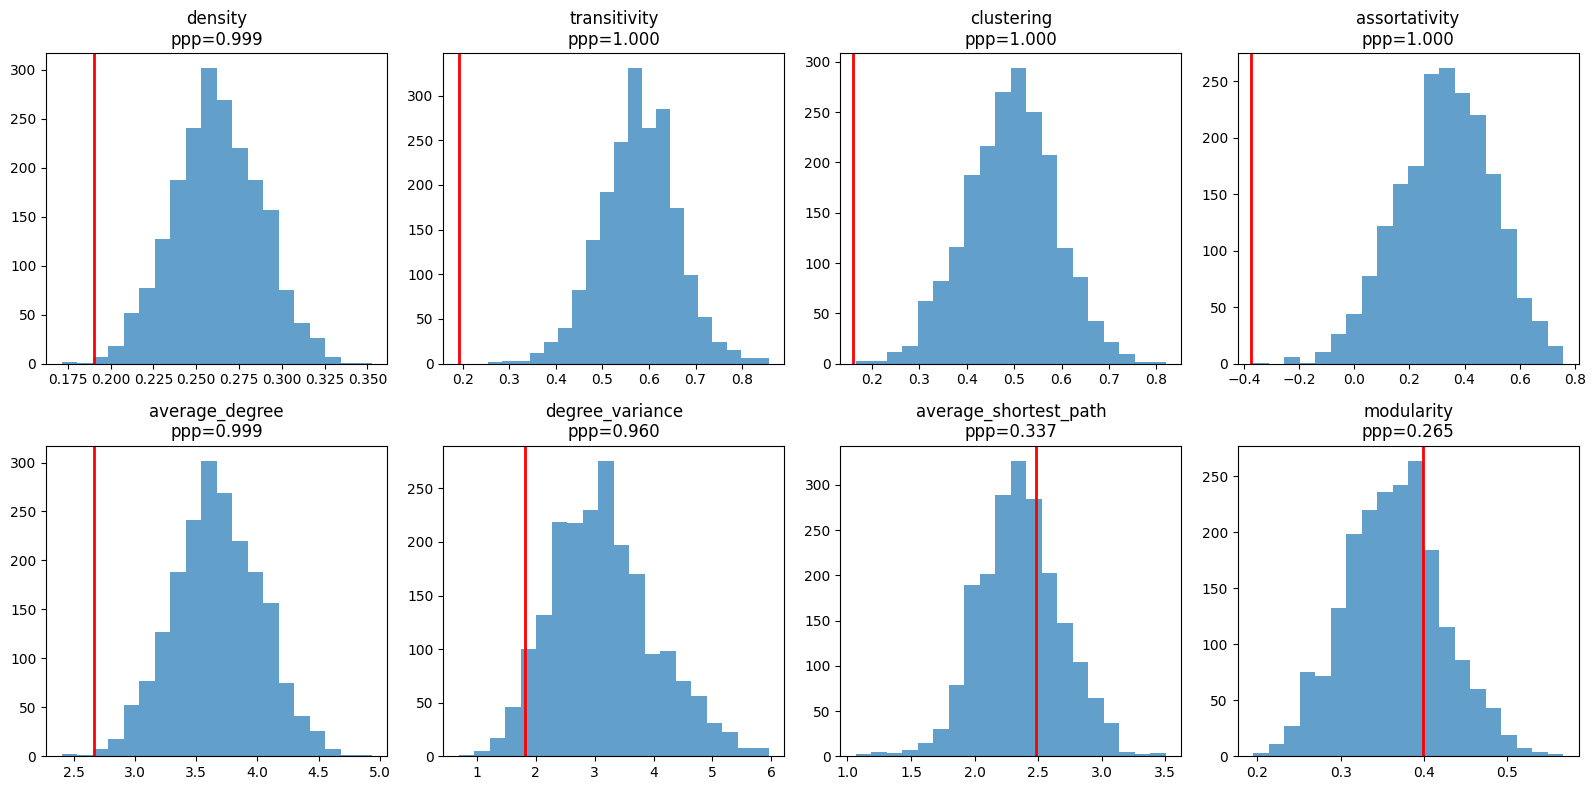

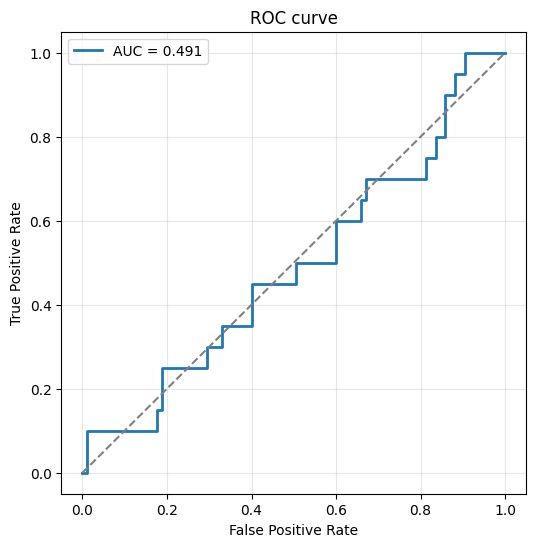

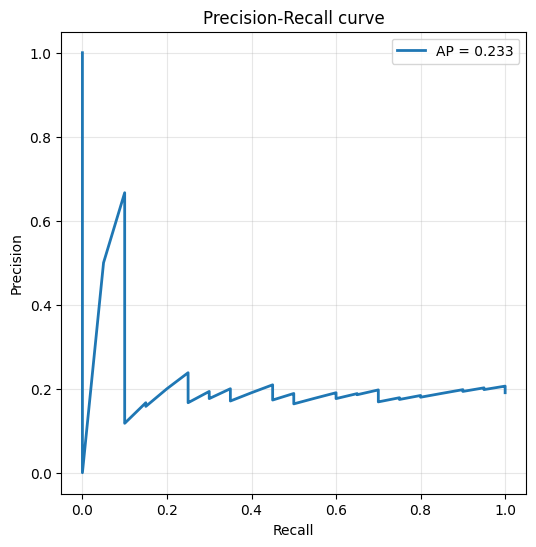

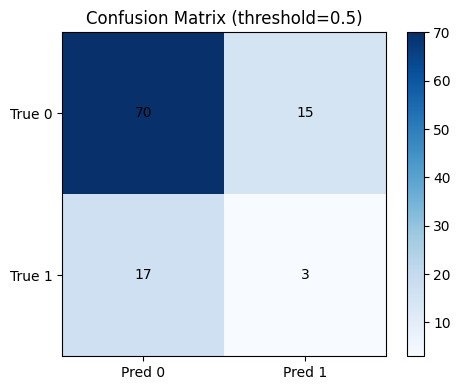

MAP:   2%|▎         | 50/2000 [00:00<00:27, 70.33it/s, logpost=-88.6823, loglik=-87.7689, logprior=-0.9134, patience=49]


{'mean_auc': 0.522888143561518, 'std_auc': 0.10263422752641922, 'min_auc': np.float64(0.3235294117647059), 'max_auc': np.float64(0.6052631578947368), 'n_folds': 5}


In [13]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_c.pkl")

### Model $\mathbb{H}^2$

#### With weights

Multi_start (1)


MAP:   1%|          | 142/20000 [00:02<06:26, 51.40it/s, logpost=-69.8339, loglik=-61.3692, logprior=-8.4647, patience=100]


[STOP] Early stopping at iter 141 (no improvement in 101 steps)

Best log-posterior: -69.8339


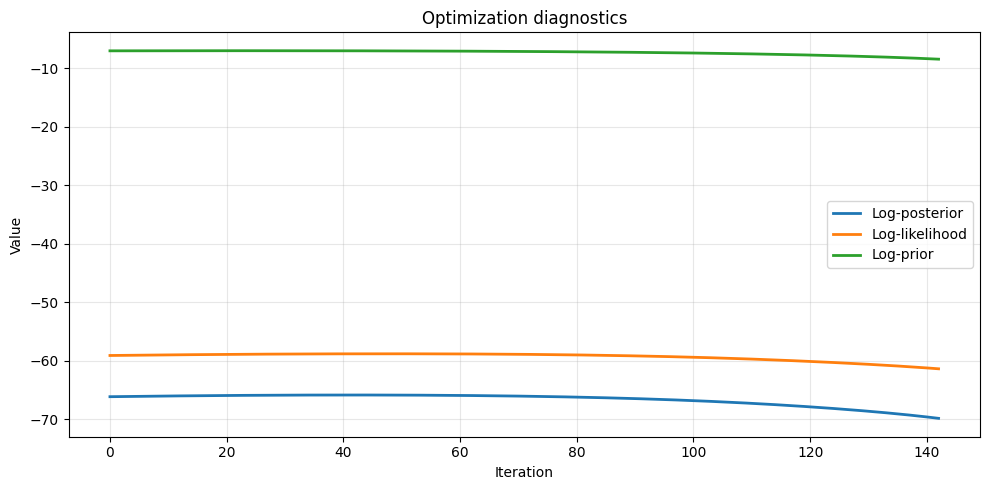

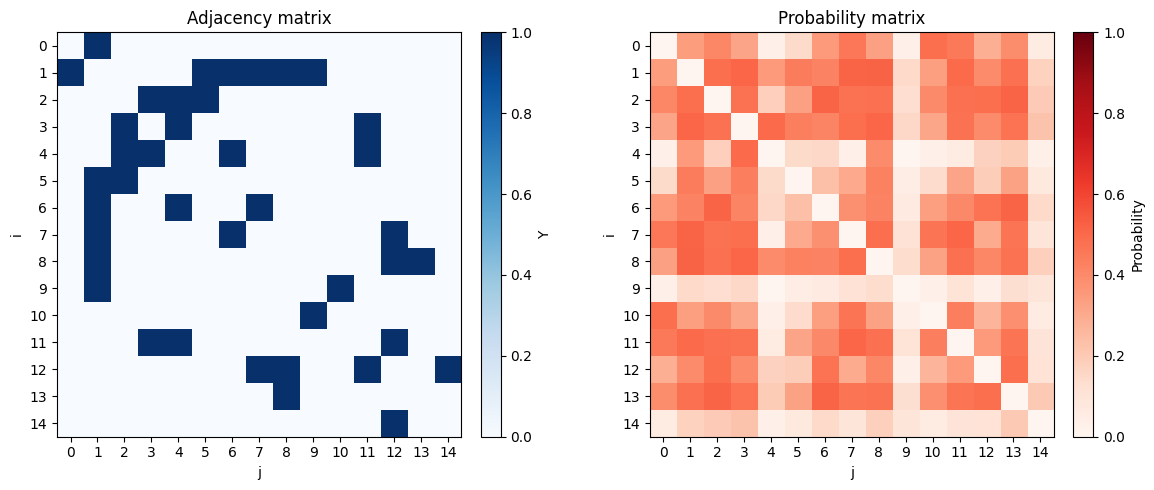

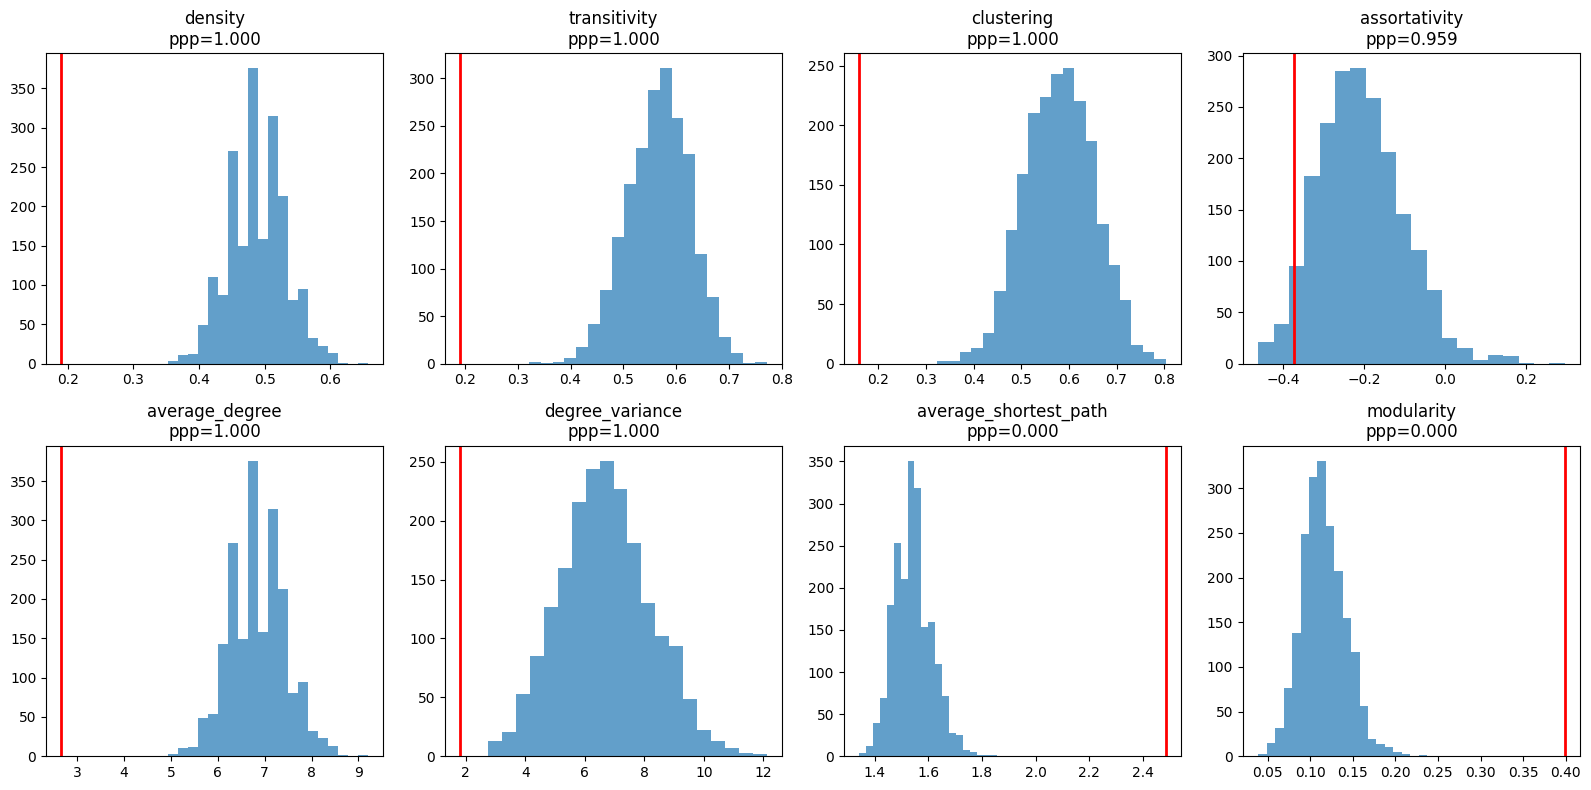

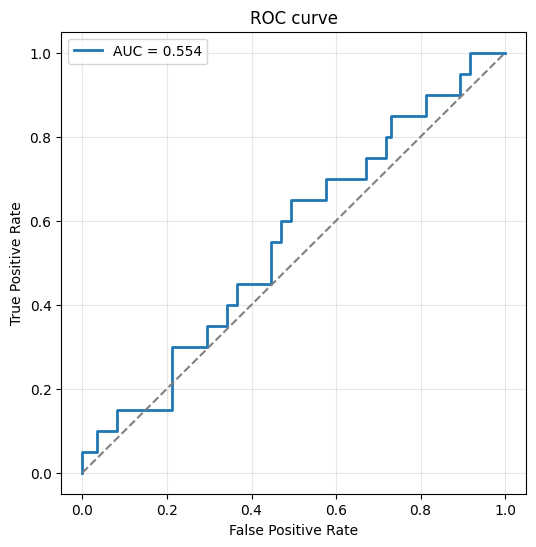

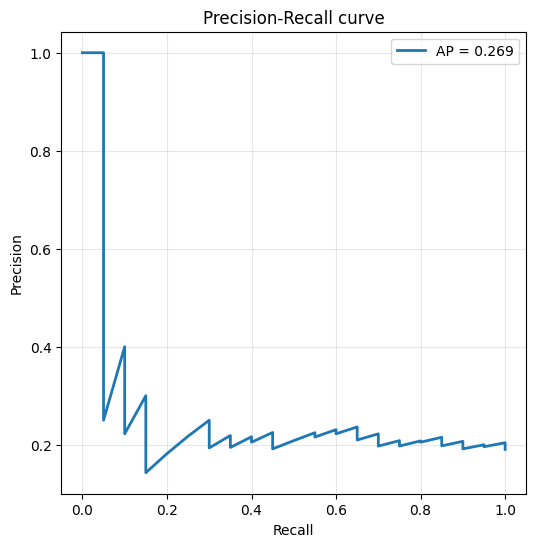

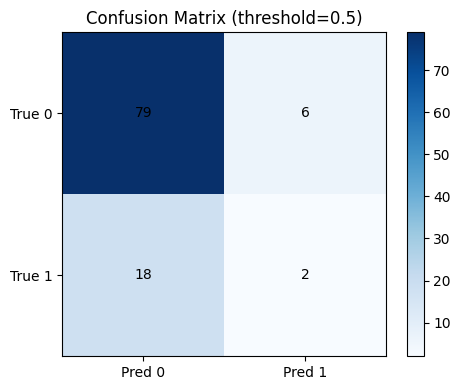

MAP:   2%|▎         | 50/2000 [00:01<00:40, 48.19it/s, logpost=nan, loglik=nan, logprior=nan, patience=49]              


{'mean_auc': 0.5341087604632496, 'std_auc': 0.16601951826851757, 'min_auc': np.float64(0.3088235294117647), 'max_auc': np.float64(0.7625), 'n_folds': 5}


In [34]:
geometry = HyperbolicGeometry(d=2)
model = LatentSpaceModel(Y=Y, geometry=geometry, sigma2_Z=1.00)
inference = MAPInference(model, lr=0.01*lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_p.pkl")

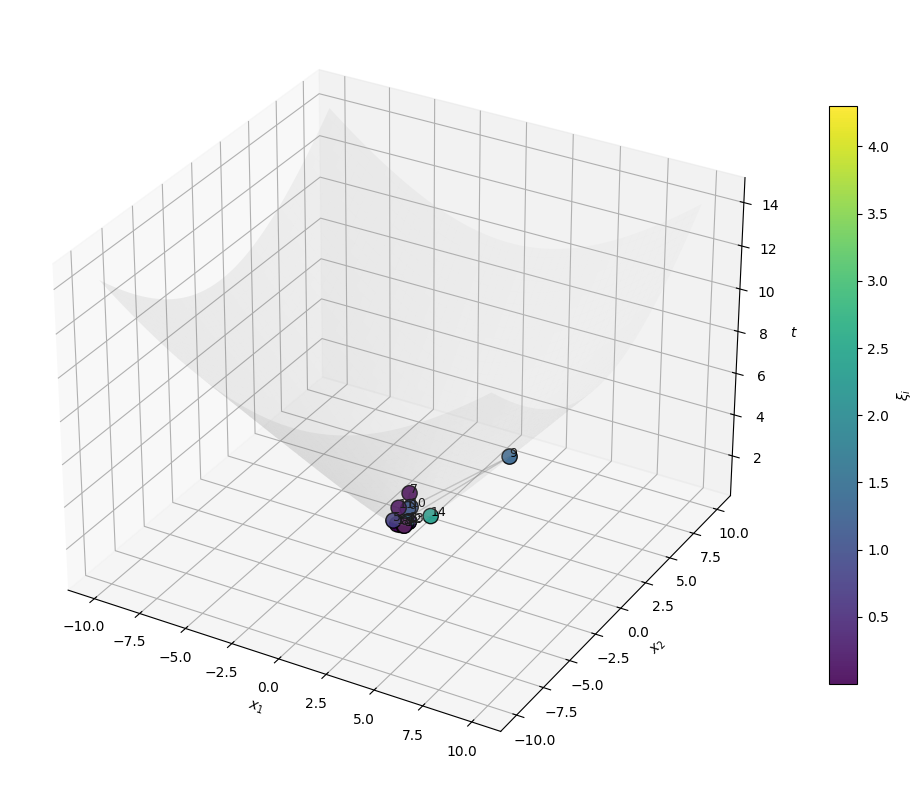

In [36]:


Z = np.array(model.inferred["MAP"]["final_params"]["Z"])
xi = np.array(model.inferred["MAP"]["final_params"]["xi"])

R = 1

# malla del hiperboloide
x = np.linspace(-diam/2, diam/2, 200)
y = np.linspace(-diam/2, diam/2, 200)

X, Y = np.meshgrid(x, y)
T = np.sqrt(R**2 + X**2 + Y**2)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# hiperboloide
ax.plot_surface(
    X,
    Y,
    T,
    alpha=0.1,
    linewidth=0,
    color="lightgray"
)

# embedding coloreado por xi
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    Z[:, 2],
    c=xi,
    cmap="viridis",
    s=120,
    edgecolors="black",
    alpha=0.9
)

# etiquetas
for i, (x_i, y_i, t_i) in enumerate(Z):
    ax.text(
        x_i,
        y_i,
        t_i,
        str(i),
        fontsize=9
    )

Y = np.array(model.Y)

for i in range(len(Z)):
    for j in range(i+1, len(Z)):
        if Y[i,j] == 1:
            ax.plot(
                [Z[i,0], Z[j,0]],
                [Z[i,1], Z[j,1]],
                [Z[i,2], Z[j,2]],
                alpha=0.4,
                linewidth=1,
                color="gray"
            )

# colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi_i$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$t$")

plt.tight_layout()
plt.show()

#### Without weights

Multi_start (1)


MAP:   8%|▊         | 822/10000 [00:07<01:20, 114.32it/s, logpost=-64.9044, loglik=-58.5505, logprior=-6.3539, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 821 (no improvement in 101 steps)

Best log-posterior: -64.9044


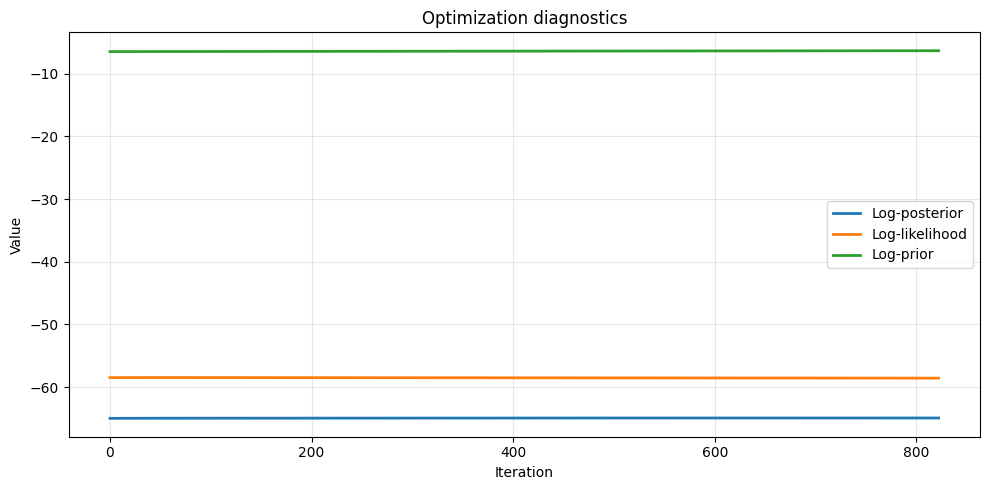

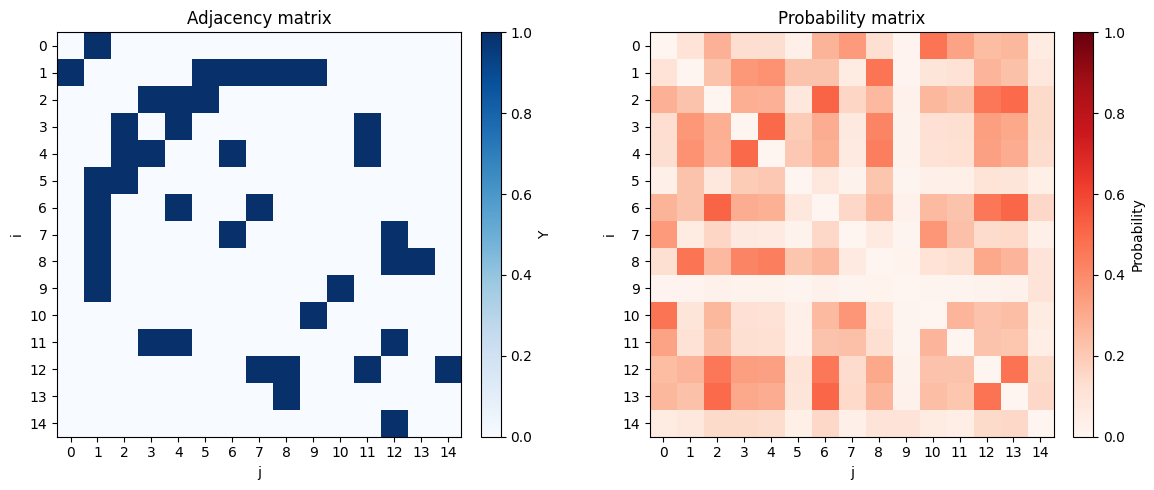

In [8]:
geometry = HyperbolicGeometry(d=2)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)}, sigma2_Z=3.0)
inference = MAPInference(model, lr=1e-3)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=10000, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
#analysis.internal_validation(n_sim=n_sim_iv)
#analysis.plot_ppc_distributions()
#analysis.laplacian_validation() 
#analysis.binary_prediction_metrics()
#analysis.plot_roc_curve()
#analysis.plot_precision_recall_curve()
#analysis.confusion_matrix(threshold=0.5)
#analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.1*lr_MAP)
#print(analysis.cross_validation_summary())

model.save("Florentine_H2_c.pkl")

In [9]:
print(model.log_likelihood())

p = model.inferred["MAP"]["final_params"]

print("alpha0 =", p["alpha0"])

D = geometry.distance_matrix(p["Z"])

print("d_min =", D[np.triu_indices(len(D),1)].min())
print("d_max =", D[np.triu_indices(len(D),1)].max())

g = model.grad_log_likelihood()

print("alpha0:", np.linalg.norm(g["alpha0"]))
print("xi:", np.linalg.norm(g["xi"]))
print("Z:", np.linalg.norm(g["Z"]))

-58.533672
alpha0 = 0.100326724
d_min = 0.041296538
d_max = 5.622943
alpha0: 0.100055605
xi: 7.348719
Z: 177.10759


## Results

### Visualization of latent spaces 

$\mathbb{R}^1$

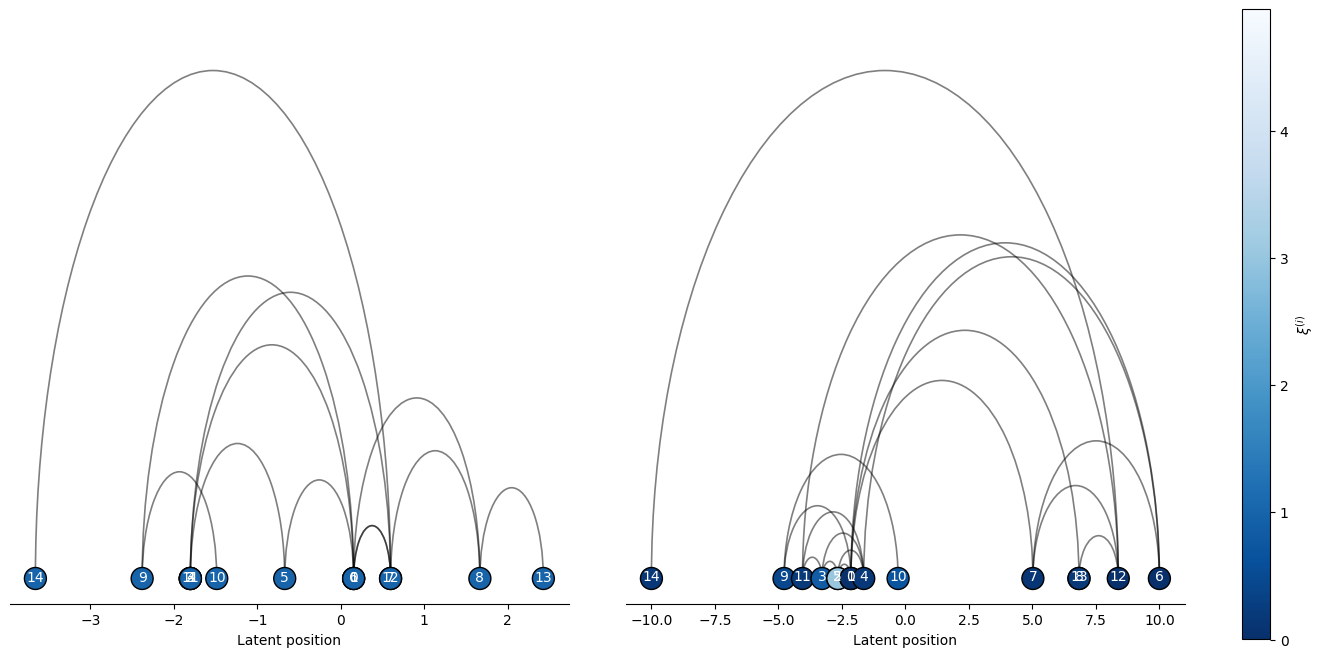

In [85]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from matplotlib.colors import Normalize
with open("Florentine_R1_p.pkl", "rb") as f:
    results_R1_p = pickle.load(f)
with open("Florentine_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)
z_p = np.asarray(results_R1_p["latent_params"]["Z"]).ravel()
xi_p = np.asarray(results_R1_p["latent_params"]["xi"]).ravel()
Y_p = np.asarray(results_R1_p["Y"])
perm_p = np.argsort(z_p)
z_p = z_p[perm_p]
xi_p = xi_p[perm_p]
Y_p = Y_p[np.ix_(perm_p, perm_p)]
labels_p = perm_p
z_c = np.asarray(results_R1_c["latent_params"]["Z"]).ravel()
Y_c = np.asarray(results_R1_c["Y"])
perm_c = np.argsort(z_c)
z_c = z_c[perm_c]
Y_c = Y_c[np.ix_(perm_c, perm_c)]
labels_c = perm_c
norm = Normalize(vmin=np.min(xi_p), vmax=np.max(xi_p))
xi_const = np.full(len(z_c), np.mean(xi_p))

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(14,7))
gs = GridSpec(1, 3, width_ratios=[1,1,0.05], wspace=0.15)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
cax = fig.add_subplot(gs[0,2])

ax = ax1
n = len(z_c)
for i in range(n):
    for j in range(i + 1, n):
        if Y_c[i, j] > 0:
            center = (z_c[i] + z_c[j]) / 2
            width = abs(z_c[j] - z_c[i])
            arc = Arc((center, 0), width=width, height=0.25 * width, theta1=0, theta2=180, lw=1.2, alpha=0.5, color="black")
            ax.add_patch(arc)
sc = ax.scatter(z_c, np.zeros(n), c=xi_const, cmap="Blues_r", norm=norm, s=250, edgecolor="black", zorder=3)
for i in range(n):
    ax.text( z_c[i],0.008,str(labels_c[i]),ha="center",va="top",fontsize=10,color="white")
ax.set_yticks([])
ax.set_xlabel("Latent position")
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_box_aspect(1)
ax = ax2
n = len(z_p)
for i in range(n):
    for j in range(i + 1, n):
        if Y_p[i, j] > 0:
            center = (z_p[i] + z_p[j]) / 2
            width = abs(z_p[j] - z_p[i])
            arc = Arc((center, 0), width=width, height=0.25 * width, theta1=0, theta2=180, lw=1.2, alpha=0.5, color="black" )
            ax.add_patch(arc)
sc = ax.scatter(z_p, np.zeros(n), c=xi_p, cmap="Blues_r", norm=norm, s=250, edgecolor="black", zorder=3)
for i in range(n):
    ax.text(z_p[i], 0.04, str(labels_p[i]), ha="center", va="top", fontsize=10, color="white")
ax.set_yticks([])
ax.set_xlabel("Latent position")
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_box_aspect(1)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label(r"$\xi^{(i)}$")
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.08, top=0.98)
plt.show()

$\mathbb{R}^2$

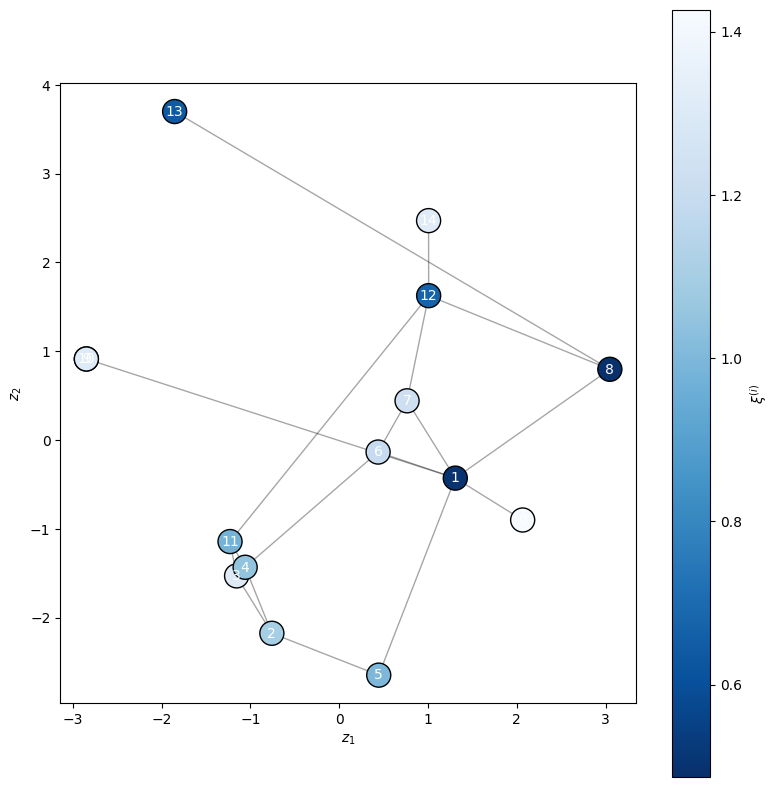

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# =====================================================
# Cargar modelo
# =====================================================

with open("Florentine_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

# =====================================================
# Extraer parámetros
# =====================================================

Z = np.asarray(results_R2_p['latent_params']['Z'])
xi = np.asarray(results_R2_p['latent_params']['xi']).ravel()
Y = np.asarray(results_R2_p['Y'])

n = len(xi)

# =====================================================
# Coordenadas latentes
# =====================================================

x = Z[:, 0]
y = Z[:, 1]

# =====================================================
# Figura
# =====================================================

fig, ax = plt.subplots(figsize=(8, 8))

# =====================================================
# Dibujar aristas observadas
# =====================================================

for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                color="black",
                alpha=0.35,
                lw=1.0,
                zorder=1
            )

# =====================================================
# Nodos
# =====================================================

norm = Normalize(
    vmin=np.min(xi),
    vmax=np.max(xi)
)

sc = ax.scatter(
    x,
    y,
    c=xi,
    cmap="Blues_r",
    norm=norm,
    s=300,
    edgecolor="black",
    zorder=3
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x[i],
        y[i],
        str(i),
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        zorder=4
    )

# =====================================================
# Barra de color
# =====================================================

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")

# =====================================================
# Estética
# =====================================================

ax.set_aspect("equal")

ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")

plt.tight_layout()
plt.show()

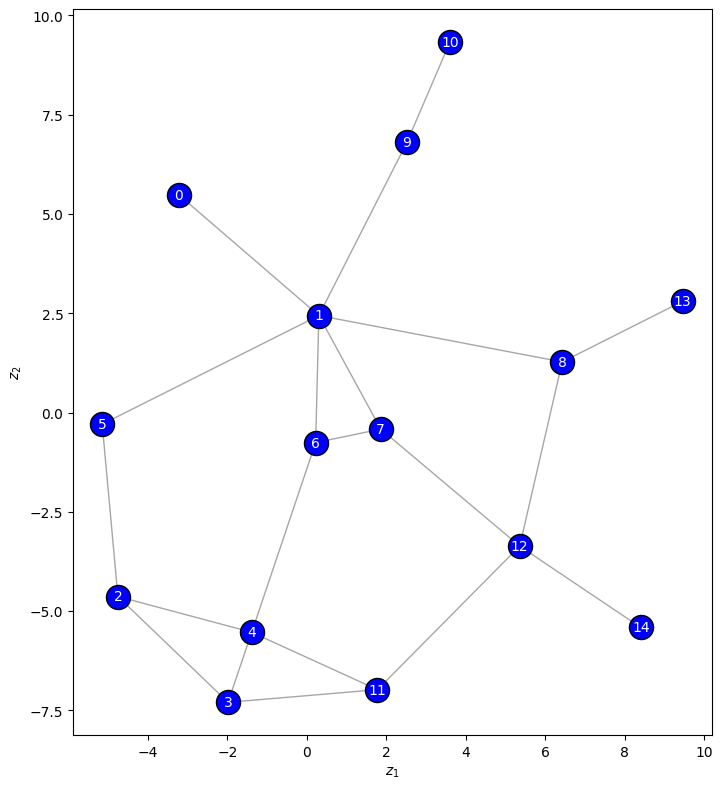

In [57]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# =====================================================
# Cargar modelo
# =====================================================

with open("Florentine_R2_c.pkl", "rb") as f:
    results_R2_c = pickle.load(f)
Z = np.asarray(results_R2_c['latent_params']['Z'])
Y = np.asarray(results_R2_c['Y'])
n = len(Z)
x = Z[:, 0]
y = Z[:, 1]
fig, ax = plt.subplots(figsize=(8, 8))
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                color="black",
                alpha=0.35,
                lw=1.0,
                zorder=1
            )

sc = ax.scatter(
    x,
    y,
    c='blue',
    s=300,
    edgecolor="black",
    zorder=3
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x[i],
        y[i],
        str(i),
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        zorder=4
    )



ax.set_aspect("equal")

ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")

plt.tight_layout()
plt.show()

$\mathbb{S}^1$

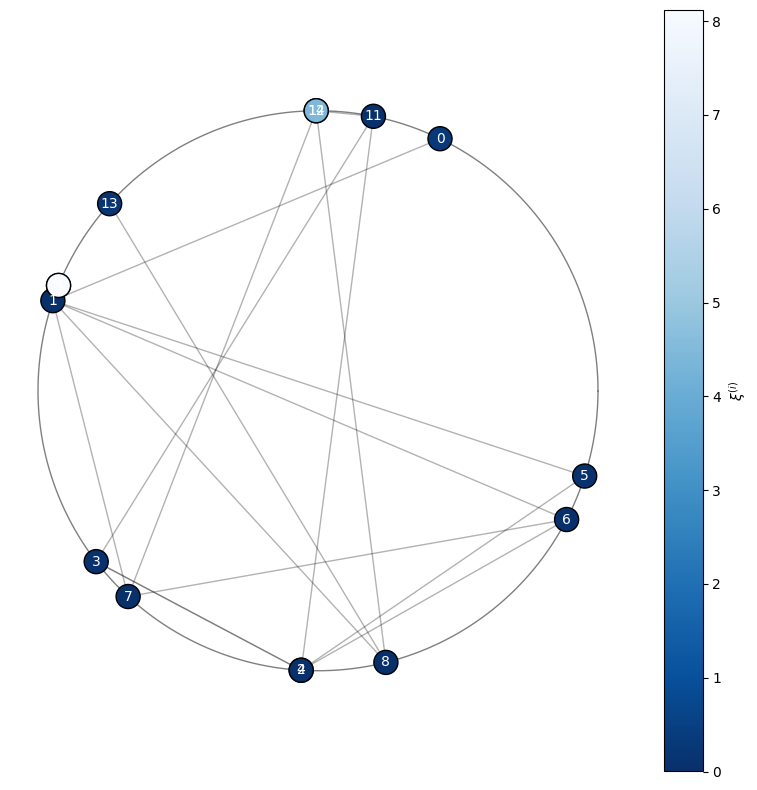

In [64]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

with open("Florentine_S1_p.pkl", "rb") as f:
    results_S1_p = pickle.load(f)
Z = np.asarray(results_S1_p["latent_params"]["Z"])
xi = np.asarray(results_S1_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_S1_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2*np.pi, 500)
R = (x[0]**2 + y[0]**2)**0.5
ax.plot(
    R*np.cos(theta),
    R*np.sin(theta),
    color="black",
    lw=1.0,
    alpha=0.5,
    zorder=0)
for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                color="black",
                alpha=0.3,
                lw=1.0,
                zorder=1
            )
norm = Normalize(
    vmin=np.min(xi),
    vmax=np.max(xi)
)

sc = ax.scatter(
    x,
    y,
    c=xi,
    cmap="Blues_r",
    norm=norm,
    s=300,
    edgecolor="black",
    zorder=3
)

for i in range(n):

    ax.text(
        x[i],
        y[i],
        str(i),
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        zorder=4
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")

ax.set_aspect("equal")

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

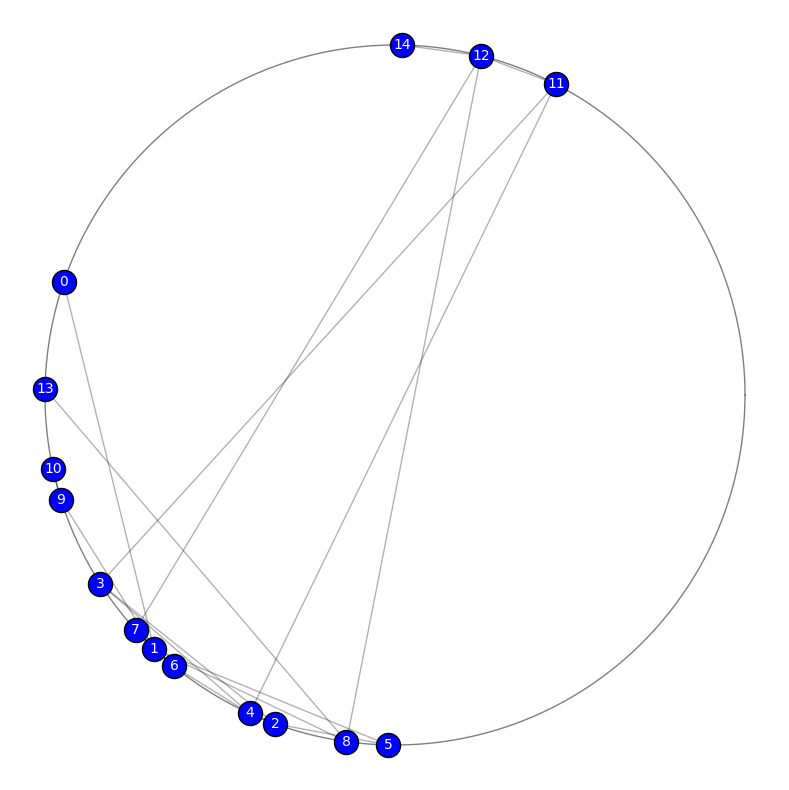

In [63]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
with open("Florentine_S1_c.pkl", "rb") as f:
    results_S1_c = pickle.load(f)
Z = np.asarray(results_S1_c["latent_params"]["Z"])
Y = np.asarray(results_S1_c["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2*np.pi, 500)
R = (x[0]**2 + y[0]**2)**0.5
ax.plot(
    R*np.cos(theta),
    R*np.sin(theta),
    color="black",
    lw=1.0,
    alpha=0.5,
    zorder=0)

for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                color="black",
                alpha=0.3,
                lw=1.0,
                zorder=1)
sc = ax.scatter(
    x,
    y,
    c='blue',
    s=300,
    edgecolor="black",
    zorder=3)
for i in range(n):
    ax.text(x[i], y[i], str(i), color="white",
        ha="center",
        va="center",
        fontsize=10,
        zorder=4)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

$\mathbb{S}^2$

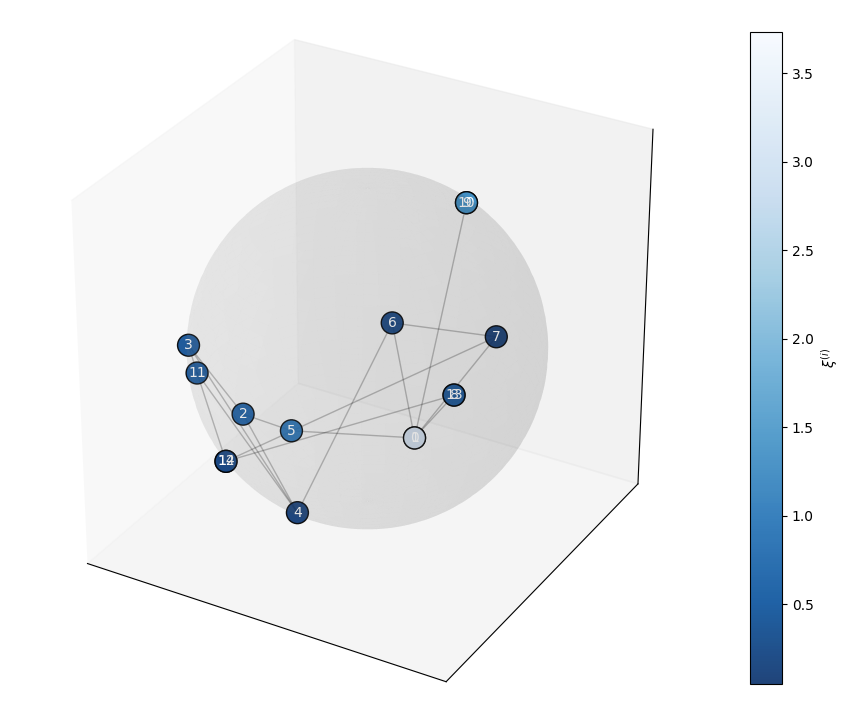

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

with open("Florentine_S2_p.pkl", "rb") as f:
    results_S2_p = pickle.load(f)


Z = np.asarray(results_S2_p["latent_params"]["Z"])
xi = np.asarray(results_S2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_S2_p["Y"])

n = len(xi)


x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
R = (x[0]**2 + y[0]**2  + z[0]**2)**0.5

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")


u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = R*np.outer(np.cos(u), np.sin(v))
ys = R*np.outer(np.sin(u), np.sin(v))
zs = R*np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    xs,
    ys,
    zs,
    alpha=0.08,
    color="gray",
    linewidth=0,
    zorder=0
)


for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                [z[i], z[j]],
                color="black",
                alpha=0.25,
                lw=1.0,
                zorder=1
            )


norm = Normalize(
    vmin=np.min(xi),
    vmax=np.max(xi)
)

sc = ax.scatter(
    x,
    y,
    z,
    c=xi,
    cmap="Blues_r",
    norm=norm,
    s=250,
    edgecolors="black",
    depthshade=True,
    zorder=3,
    alpha=0.9
)

for i in range(n):

    ax.text(
        x[i],
        y[i],
        z[i],
        str(i),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        alpha=1.0)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1,1,1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)
plt.tight_layout()
plt.show()

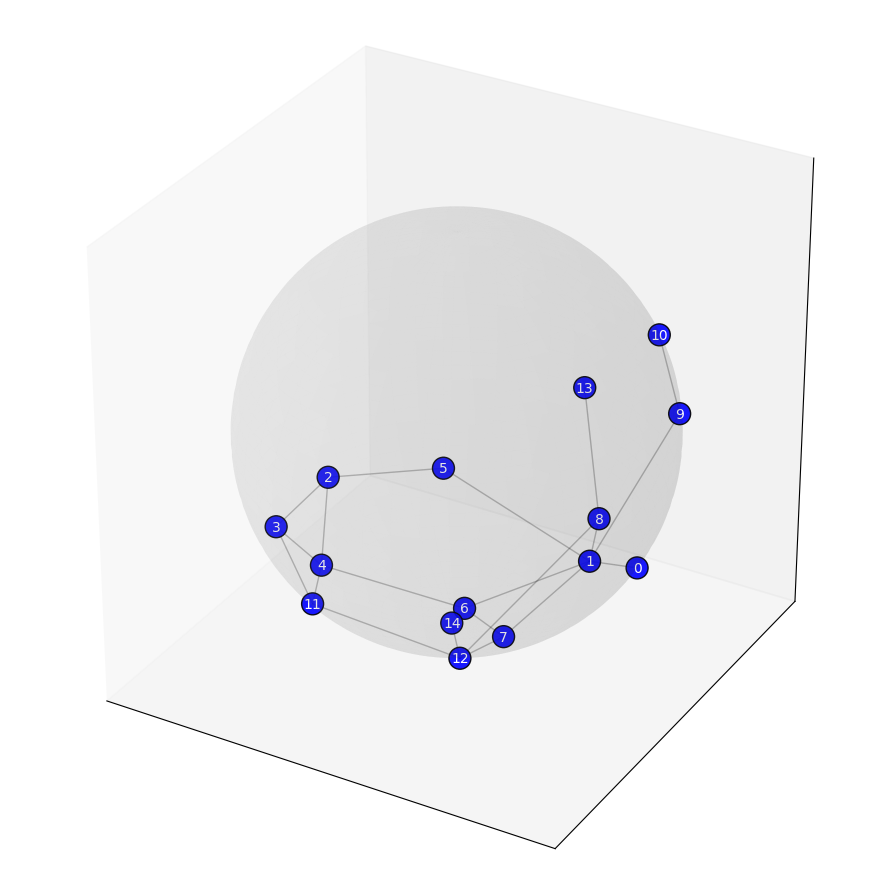

In [70]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

with open("Florentine_S2_c.pkl", "rb") as f:
    results_S2_c = pickle.load(f)


Z = np.asarray(results_S2_c["latent_params"]["Z"])
Y = np.asarray(results_S2_c["Y"])

n = len(xi)


x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
R = (x[0]**2 + y[0]**2  + z[0]**2)**0.5

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")


u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = R*np.outer(np.cos(u), np.sin(v))
ys = R*np.outer(np.sin(u), np.sin(v))
zs = R*np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    xs,
    ys,
    zs,
    alpha=0.08,
    color="gray",
    linewidth=0,
    zorder=0
)


for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                [z[i], z[j]],
                color="black",
                alpha=0.25,
                lw=1.0,
                zorder=1
            )


sc = ax.scatter(
    x,
    y,
    z,
    c='blue',
    s=250,
    edgecolors="black",
    depthshade=True,
    zorder=3,
    alpha=0.9
)

for i in range(n):

    ax.text(
        x[i],
        y[i],
        z[i],
        str(i),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        alpha=1.0)
ax.set_box_aspect([1,1,1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)
plt.tight_layout()
plt.show()

$\mathbb{H}^1$

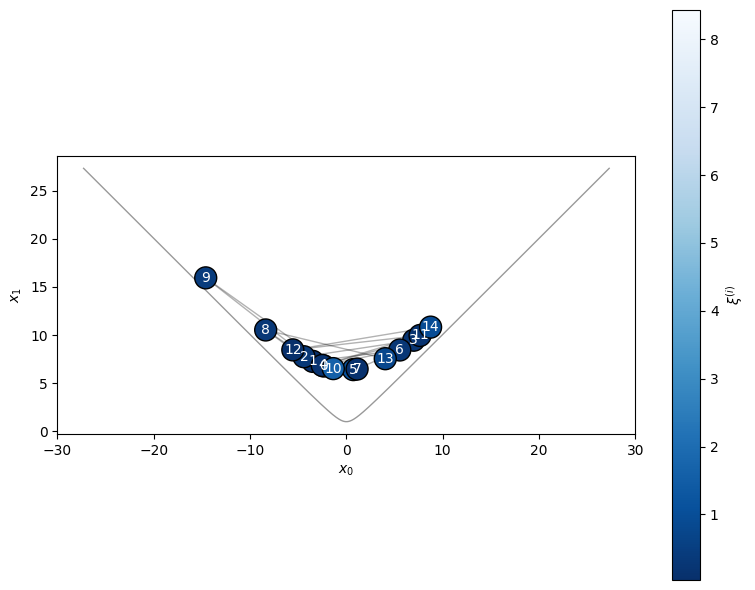

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# =====================================================
# Cargar modelo
# =====================================================

with open("Florentine_H1_p.pkl", "rb") as f:
    results_H1_p = pickle.load(f)

# =====================================================
# Extraer parámetros
# =====================================================

Z = np.asarray(results_H1_p["latent_params"]["Z"])
xi = np.asarray(results_H1_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H1_p["Y"])

n = len(xi)

# =====================================================
# Coordenadas sobre H¹
# =====================================================

x0 = Z[:, 0]
x1 = Z[:, 1]

# =====================================================
# Figura
# =====================================================

fig, ax = plt.subplots(figsize=(8, 6))

# =====================================================
# Hipérbola unidad
# =====================================================

t = np.linspace(-4, 4, 1000)

ax.plot(
    np.sinh(t),
    np.cosh(t),
    color="black",
    alpha=0.4,
    lw=1.0
)

# =====================================================
# Aristas observadas
# =====================================================

for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x0[i], x0[j]],
                [x1[i], x1[j]],
                color="black",
                alpha=0.3,
                lw=1.0,
                zorder=1
            )

# =====================================================
# Nodos
# =====================================================

norm = Normalize(
    vmin=np.min(xi),
    vmax=np.max(xi)
)

sc = ax.scatter(
    x0,
    x1,
    c=xi,
    cmap="Blues_r",
    norm=norm,
    s=250,
    edgecolor="black",
    zorder=3
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x0[i],
        x1[i],
        str(i),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        zorder=4
    )

# =====================================================
# Barra de color
# =====================================================

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")

# =====================================================
# Estética
# =====================================================

ax.set_aspect("equal")

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")

plt.tight_layout()
plt.show()

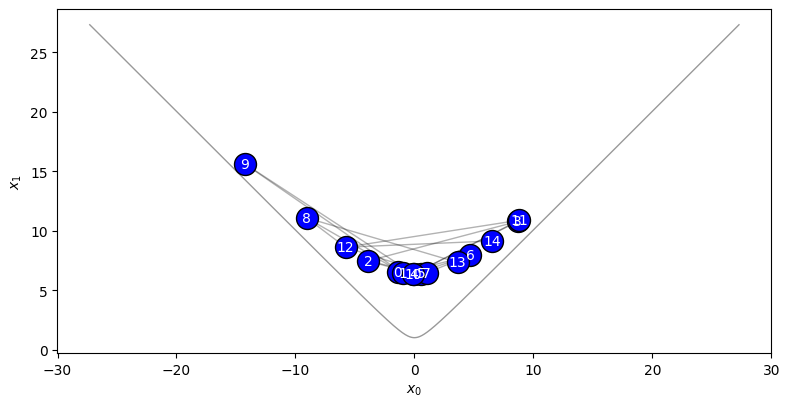

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

with open("Florentine_H1_c.pkl", "rb") as f:
    results_H1_c = pickle.load(f)

# =====================================================
# Extraer parámetros
# =====================================================

Z = np.asarray(results_H1_c["latent_params"]["Z"])
Y = np.asarray(results_H1_c["Y"])

n = len(xi)

# =====================================================
# Coordenadas sobre H¹
# =====================================================

x0 = Z[:, 0]
x1 = Z[:, 1]

# =====================================================
# Figura
# =====================================================

fig, ax = plt.subplots(figsize=(8, 6))

# =====================================================
# Hipérbola unidad
# =====================================================

t = np.linspace(-4, 4, 1000)

ax.plot(
    np.sinh(t),
    np.cosh(t),
    color="black",
    alpha=0.4,
    lw=1.0
)

# =====================================================
# Aristas observadas
# =====================================================

for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x0[i], x0[j]],
                [x1[i], x1[j]],
                color="black",
                alpha=0.3,
                lw=1.0,
                zorder=1
            )

# =====================================================
# Nodos
# =====================================================


sc = ax.scatter(
    x0,
    x1,
    c='blue',
    s=250,
    edgecolor="black",
    zorder=3
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x0[i],
        x1[i],
        str(i),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        zorder=4
    )

# =====================================================
# Estética
# =====================================================

ax.set_aspect("equal")

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")

plt.tight_layout()
plt.show()

$\mathbb{H}^2$

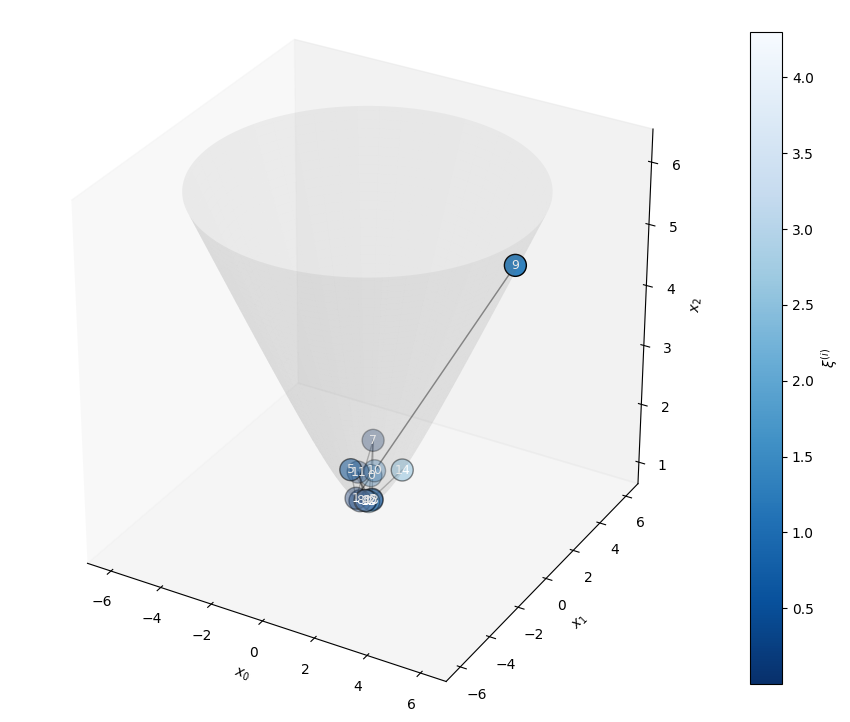

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# Cargar modelo
# =====================================================

with open("Florentine_H2_p.pkl", "rb") as f:
    results_H2_p = pickle.load(f)

# =====================================================
# Extraer parámetros
# =====================================================

Z = np.asarray(results_H2_p["latent_params"]["Z"])
xi = np.asarray(results_H2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H2_p["Y"])

n = len(xi)

# =====================================================
# Coordenadas Lorentz
# =====================================================

x0 = Z[:, 0]
x1 = Z[:, 1]
x2 = Z[:, 2]

# =====================================================
# Figura
# =====================================================

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection="3d")

# =====================================================
# Hiperboloide
# =====================================================

rmax = np.max(np.sqrt(x1**2 + x2**2)) * 1.1

r = np.linspace(0, rmax, 100)
theta = np.linspace(0, 2*np.pi, 150)

R, Theta = np.meshgrid(r, theta)

X1 = R * np.cos(Theta)
X2 = R * np.sin(Theta)

X0 = np.sqrt(1 + X1**2 + X2**2)

ax.plot_surface(
    X1,
    X2,
    X0,
    alpha=0.08,
    color="gray",
    linewidth=0,
    antialiased=True
)

# =====================================================
# Aristas observadas
# =====================================================

for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x0[i], x0[j]],
                [x1[i], x1[j]],
                [x2[i], x2[j]],
                color="black",
                alpha=0.25,
                lw=1.0
            )

# =====================================================
# Nodos
# =====================================================

norm = Normalize(
    vmin=np.min(xi),
    vmax=np.max(xi)
)

sc = ax.scatter(
    x0,
    x1,
    x2,
    c=xi,
    cmap="Blues_r",
    norm=norm,
    s=250,
    edgecolors="black",
    depthshade=True
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x0[i],
        x1[i],
        x2[i],
        str(i),
        color="white",
        fontsize=9,
        ha="center",
        va="center"
    )

# =====================================================
# Barra de color
# =====================================================

cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")

# =====================================================
# Estética
# =====================================================

ax.set_box_aspect([1,1,1])

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")
ax.set_zlabel(r"$x_2$")

ax.grid(False)

plt.tight_layout()
plt.show()

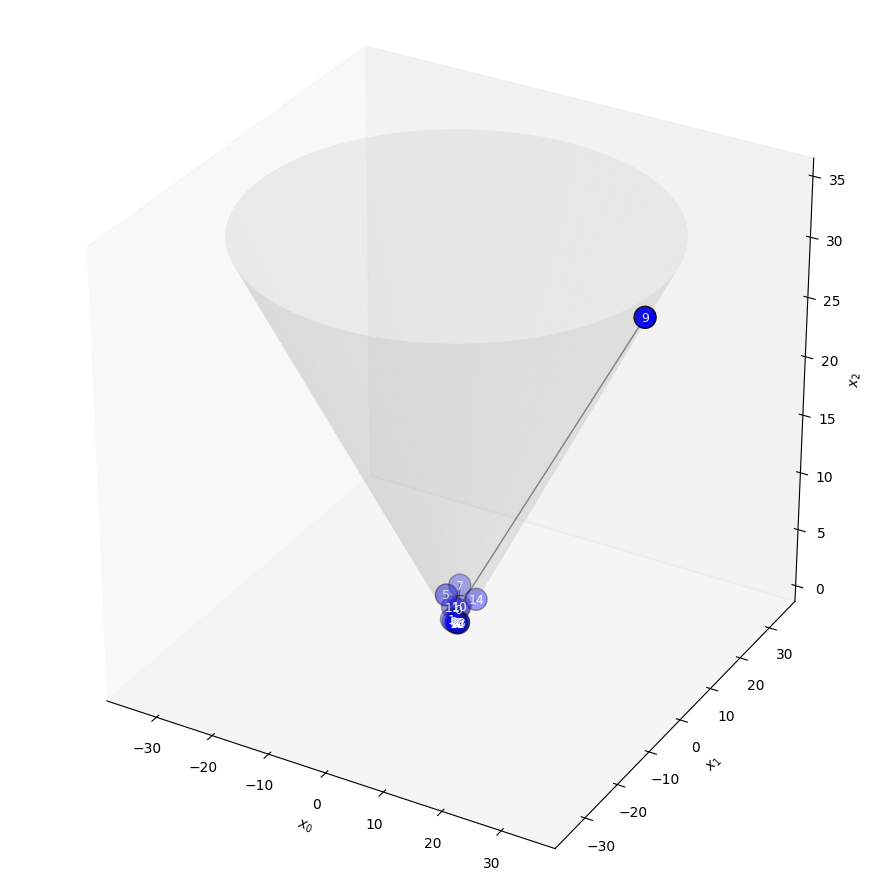

In [81]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# Cargar modelo
# =====================================================

with open("Florentine_H2_c.pkl", "rb") as f:
    results_H2_c = pickle.load(f)

# =====================================================
# Extraer parámetros
# =====================================================

Z = np.asarray(results_H2_c["latent_params"]["Z"])
Y = np.asarray(results_H2_c["Y"])

n = len(Z)

# =====================================================
# Coordenadas Lorentz
# =====================================================

x0 = Z[:, 0]
x1 = Z[:, 1]
x2 = Z[:, 2]

# =====================================================
# Figura
# =====================================================

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection="3d")

# =====================================================
# Hiperboloide
# =====================================================

rmax = np.max(np.sqrt(x1**2 + x2**2)) * 1.1

r = np.linspace(0, rmax, 100)
theta = np.linspace(0, 2*np.pi, 150)

R, Theta = np.meshgrid(r, theta)

X1 = R * np.cos(Theta)
X2 = R * np.sin(Theta)

X0 = np.sqrt(1 + X1**2 + X2**2)

ax.plot_surface(
    X1,
    X2,
    X0,
    alpha=0.08,
    color="gray",
    linewidth=0,
    antialiased=True
)

# =====================================================
# Aristas observadas
# =====================================================

for i in range(n):
    for j in range(i + 1, n):

        if Y[i, j] > 0:

            ax.plot(
                [x0[i], x0[j]],
                [x1[i], x1[j]],
                [x2[i], x2[j]],
                color="black",
                alpha=0.25,
                lw=1.0
            )


sc = ax.scatter(
    x0,
    x1,
    x2,
    c='blue',
    s=250,
    edgecolors="black",
    depthshade=True
)

# =====================================================
# Etiquetas
# =====================================================

for i in range(n):

    ax.text(
        x0[i],
        x1[i],
        x2[i],
        str(i),
        color="white",
        fontsize=9,
        ha="center",
        va="center"
    )

# =====================================================
# Estética
# =====================================================

ax.set_box_aspect([1,1,1])

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")
ax.set_zlabel(r"$x_2$")

ax.grid(False)

plt.tight_layout()
plt.show()

### Visualization of probability matrices

### Model statistics

### Internal validation

### External validation